In [18]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


🏦 HOME LOAN DEFAULT PREDICTION
        │
        ├── Project Overview
        │
        ├── Problem Statement
        │
        ├── Business Objective
        │
        ├── Dataset Description
        │
        ├── Understanding 7 Tables
        │
        ├── Data Loading
        │
        ├── EDA
        │
        ├── Feature Engineering
        │
        ├── Data Merging
        │
        ├── Preprocessing
        │
        ├── ML Models
        │
        ├── Model Comparison
        │
        ├── Threshold Optimization
        │
        ├── SHAP
        │
        ├── Risk Segmentation
        │
        ├── Calibration
        │
        └── Final Conclusion

# 🏦 HOME LOAN DEFAULT PREDICTION

## PRCP-1006 — Data Science Internship Project

---

# 1. Project Overview

Home Loan Default Prediction is a machine learning project designed to identify customers who may have a higher probability of defaulting on a home loan.

The project combines current loan application information with historical financial behavior from multiple related datasets.

The complete workflow includes data understanding, cleaning, exploratory data analysis, feature engineering, data integration, preprocessing, machine learning, model evaluation, explainability, risk segmentation, and calibration.

Four classification algorithms were evaluated: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

Gradient Boosting achieved the best cross-validation ROC-AUC of **0.7348** and was selected as the final model.

The project is designed as a decision-support system and should not be treated as an automated real-world loan approval/rejection system.

---

# 2. Problem Statement

Financial institutions face financial risk when customers fail to repay loans.

The objective of this project is to predict whether a customer is likely to default based on application information and historical financial behavior.

The target variable is `TARGET`, where **0 represents a non-default customer and 1 represents a default customer**.

The project also aims to identify the major factors associated with default risk.

Because the default class represents only approximately **7%** of the dataset, the problem is treated as an imbalanced binary classification problem.

---

# 3. Business Objective

The main business objective is to help financial institutions identify potentially high-risk loan applications.

The model estimates the probability that a customer may default rather than simply producing a yes/no prediction.

This information can help credit analysts prioritize applications for additional verification or manual review.

The project also provides risk segmentation and SHAP-based explanations to understand why a customer receives a particular risk score.

The model is intended to support human decision-making rather than replace financial experts or regulatory processes.

---

# 4. Dataset Description

The project uses seven interconnected datasets containing current application information and historical financial behavior.

The primary customer identifier is `SK_ID_CURR`, which is used to connect records belonging to the same customer.

The main dataset is `application_train.csv`, which contains the current application and the target variable.

Historical datasets provide information about previous credits, loan applications, POS/CASH behavior, credit cards, and installment payments.

Historical records were aggregated to the customer level before being merged with the main application dataset.

---

# 5. The Seven Dataset Tables

## 5.1 application_train.csv

This is the main/current loan application dataset.

It contains customer demographic, financial, employment, loan, and application-related information.

Important features include `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`, `DAYS_BIRTH`, and `DAYS_EMPLOYED`.

It also contains the target variable `TARGET`.

`TARGET = 0` represents non-default and `TARGET = 1` represents default.

This dataset was used as the base table for the final customer-level modeling dataset.

---

## 5.2 bureau.csv

The Bureau dataset contains information about previous credits obtained by customers from other financial institutions.

Important variables include previous credit amount, outstanding debt, overdue amounts, credit status, and credit history duration.

Multiple bureau records can belong to the same customer.

Therefore, these records were aggregated into customer-level features.

Examples include `PREVIOUS_CREDIT_COUNT`, `TOTAL_CREDIT`, `TOTAL_DEBT`, and delinquency-related indicators.

These features help the model understand previous credit exposure and financial behavior.

---

## 5.3 bureau_balance.csv

`bureau_balance.csv` contains monthly status information related to previous bureau credits.

It provides a more detailed view of how customers behaved during their historical credit periods.

Monthly credit status information was converted into customer-level delinquency indicators.

Features such as `TOTAL_DELINQUENT_MONTHS`, `MAX_DELINQUENT_STATUS`, and `TOTAL_CREDIT_HISTORY_MONTHS` were created.

These features help identify customers with previous repayment difficulties.

The table was connected to bureau credit records through the historical credit identifier and ultimately aggregated to the customer level.

---

## 5.4 previous_application.csv

This table contains information about customers' previous loan applications.

A customer may have multiple previous applications with different outcomes such as approved, refused, cancelled, or unused offers.

We created customer-level features such as `TOTAL_PREVIOUS_APPLICATIONS`, `TOTAL_APPROVED_APPLICATIONS`, and `TOTAL_REFUSED_APPLICATIONS`.

Additional features included total application amounts, previous credit amounts, approval rate, and refusal rate.

These variables describe the customer's previous borrowing and application behavior.

This information can provide additional context about historical credit demand and application outcomes.

---

## 5.5 POS_CASH_balance.csv

This dataset contains monthly information about POS and cash loans.

Features include balances, installment information, active/completed loan status, and Days Past Due (DPD).

DPD represents the number of days by which a payment is overdue.

Customer-level features such as `TOTAL_ACTIVE_LOANS`, `TOTAL_COMPLETED_LOANS`, `MAX_DPD`, and `TOTAL_DPD` were created.

These features help capture historical repayment and delinquency behavior.

Higher delinquency can indicate potential financial repayment difficulties.

---

## 5.6 credit_card_balance.csv

This dataset contains historical credit card balances and payment behavior.

It includes information such as credit limits, balances, drawings, payments, and delinquency indicators.

We created features such as `AVERAGE_CREDIT_CARD_BALANCE`, `AVERAGE_CREDIT_LIMIT`, `AVERAGE_CREDIT_UTILIZATION`, and `TOTAL_PAYMENTS`.

Credit utilization was calculated as credit card balance divided by available credit limit.

High utilization can indicate greater dependence on available credit.

These features provide additional information about a customer's financial pressure and credit usage behavior.

---

## 5.7 installments_payments.csv

This table contains historical installment payment records.

It provides information about expected installment amounts, actual payment amounts, payment dates, and installment dates.

We created features including `TOTAL_PAYMENT_AMOUNT`, `AVERAGE_PAYMENT_DELAY`, `TOTAL_LATE_PAYMENTS`, and `TOTAL_UNDERPAYMENTS`.

Payment delay was calculated by comparing the actual payment date with the scheduled installment date.

This allows the model to identify historical repayment delays and underpayment behavior.

Installment history is particularly useful because it reflects actual customer repayment behavior.

---

# 6. Data Integration

The seven datasets were not directly concatenated because historical tables contain multiple records for the same customer.

For example, one customer may have several previous applications and many installment records.

Directly joining these tables could create duplicate customer rows and an unnecessarily large dataset.

Instead, historical records were aggregated using counts, sums, averages, maximum values, and behavioral indicators.

The resulting customer-level features were then merged with `application_train` using `SK_ID_CURR`.

---

# 7. Data Loading

The datasets were loaded using the Pandas library.

Pandas provides functions for reading CSV files, inspecting data, handling missing values, grouping records, merging datasets, and creating new features.

The project data was organized into a dedicated `data` directory.

The main application dataset was used as the base dataset.

Historical datasets were loaded separately and processed before merging.

For computational purposes, sampled historical records were used during the feature-engineering workflow.

---

# 8. Exploratory Data Analysis — EDA

Exploratory Data Analysis is the process of understanding the structure, distribution, relationships, and quality of the data before building machine learning models.

EDA was performed using summary statistics, distributions, boxplots, countplots, and correlation analysis.

The analysis examined customer demographics, financial variables, employment information, credit behavior, and default patterns.

The target distribution was also analyzed to identify class imbalance.

EDA helped identify important risk-related patterns and guided the feature-engineering process.

---

# 9. Class Imbalance

Class imbalance occurs when one target class contains significantly more observations than another.

Our final modeling dataset contains **930 non-default customers and only 70 default customers**.

Therefore, the default rate is approximately **7%**.

A model predicting every customer as non-default could achieve approximately 93% accuracy while detecting zero defaulters.

Therefore, accuracy alone is not an appropriate primary metric for this project.

Class weighting, stratified sampling, Recall, F1-score, ROC-AUC, PR-AUC, and threshold optimization were used to address this issue.

---

# 10. Missing Value Handling

Missing values represent observations where information is unavailable.

The datasets contained missing values in several numerical and categorical variables.

Numerical variables were handled using appropriate imputation strategies, while categorical variables were assigned an `"Unknown"` category where appropriate.

Historical features were filled with zero when a customer had no corresponding historical record in the sampled data.

After the data-cleaning process, the final modeling dataset contained no missing values.

Proper missing-value treatment prevents errors and allows machine learning algorithms to work with a complete feature matrix.

---

# 11. Duplicate Detection

Duplicate records can cause certain customers to receive excessive importance during model training.

The customer identifier `SK_ID_CURR` was checked for duplicate records in the main application dataset.

The final application sample contained no duplicate customer identifiers.

Historical tables naturally contain multiple records per customer, so those were not treated as duplicate customers.

Instead, historical records were aggregated before merging.

This produced one final modeling row per customer.

---

# 12. Constant Feature Removal

A constant feature has the same value for every observation.

Such a feature contains no variation and therefore cannot help a classification model distinguish between defaulters and non-defaulters.

A total of **25 constant features** were identified during data cleaning.

These features were removed from the dataset.

This reduced the intermediate dataset from **183 features to 158 features**.

Removing constant variables reduces unnecessary dimensionality and simplifies the feature space.

---

# 13. DAYS_EMPLOYED Anomaly

The `DAYS_EMPLOYED` variable contained an unrealistic value of `365243` for some observations.

This value corresponds to an extremely large employment duration and is treated as an anomaly in the dataset.

Positive anomalous values were replaced with missing values.

The missing values were then imputed using the median of valid employment-duration observations.

The cleaned variable was transformed into a more interpretable employment duration measured in years.

This improved the quality and interpretability of the employment-related feature.

---

# 14. Feature Engineering

Feature engineering is the process of creating meaningful variables from existing data.

It is important because raw variables may not directly represent the relationships that are useful for predicting default.

We created customer-level historical features from the seven datasets.

We also created age, employment duration, financial ratios, payment behavior, delinquency indicators, approval rates, and credit utilization features.

Feature engineering helped transform raw financial records into meaningful customer-level risk indicators.

---

# 15. Age Feature

The original `DAYS_BIRTH` variable represents customer age in negative days.

It was transformed into:

`AGE_YEARS = -DAYS_BIRTH / 365.25`

This makes the feature easier to understand and interpret.

The average customer age in the final modeling dataset was approximately **43.46 years**.

The analysis showed that defaulting customers had a lower average age than non-defaulting customers in our sample.

This is an observed association in the dataset and should not be interpreted as a causal relationship.

---

# 16. Employment Years

The cleaned employment duration was converted from days into years.

The resulting feature was:

`EMPLOYMENT_YEARS = -DAYS_EMPLOYED / 365.25`

The average employment duration was approximately **6.08 years**.

Defaulting customers had an average employment duration of approximately **3.73 years**, compared with approximately **6.25 years** for non-defaulters.

This indicates that shorter employment history was associated with higher default risk in the sample.

---

# 17. Credit-to-Income Ratio

`CREDIT_INCOME_RATIO` was calculated as:

`AMT_CREDIT / AMT_INCOME_TOTAL`

It measures the requested credit relative to customer income.

A higher ratio indicates that the requested loan is large compared with the customer's income.

The average ratio was approximately **3.92** for non-defaulters and **4.34** for defaulters.

This suggests that higher credit exposure relative to income was associated with increased default risk in our sample.

The feature became one of the important predictors during model explainability analysis.

---

# 18. Annuity-to-Income Ratio

`ANNUITY_INCOME_RATIO` measures the loan annuity relative to customer income.

It was calculated as:

`AMT_ANNUITY / AMT_INCOME_TOTAL`

The ratio provides an approximate representation of repayment burden relative to income.

The average ratio was approximately **0.179** for non-defaulters and **0.201** for defaulters.

Higher repayment burden was therefore associated with higher observed default risk.

This feature provides more contextual information than examining income or annuity separately.

---

# 19. Credit-to-Goods Ratio

`CREDIT_GOODS_RATIO` was calculated as:

`AMT_CREDIT / AMT_GOODS_PRICE`

This compares the requested credit amount with the value of the associated goods or property.

The average ratio was approximately **1.118** for non-defaulters and **1.167** for defaulters.

Higher values were associated with increased default risk in the sample.

The feature was also identified as an important predictor through SHAP analysis.

---

# 20. Income per Family Member

`INCOME_PER_FAMILY_MEMBER` was calculated using:

`AMT_INCOME_TOTAL / CNT_FAM_MEMBERS`

This provides an approximate measure of income available relative to family size.

The feature can provide additional context about the financial resources available within a household.

It was retained as an engineered financial feature.

Extreme values were investigated using the IQR method rather than automatically deleted.

This was done because extreme financial values may represent legitimate customers.

---

# 21. Outlier Detection

Outliers are observations that are unusually far from the central distribution.

The Interquartile Range (IQR) method was used to identify extreme values in engineered financial ratios.

Outliers were identified in credit-to-income, annuity-to-income, credit-to-goods, and income-per-family-member ratios.

The identified observations were not automatically removed.

Financial datasets can legitimately contain high-income, high-credit, or unusual customers.

Therefore, the project retained these observations while applying preprocessing and model-based techniques.

---

# 22. Train-Test Split

The dataset was divided into training and testing subsets.

The training set contains **800 customers**, while the test set contains **200 customers**.

A stratified split was used to preserve the proportion of default and non-default cases.

This is important because the dataset is highly imbalanced.

The training data was used to fit the models, while the test data was kept separate for final evaluation.

This helps provide a more realistic estimate of model performance on unseen data.

---

# 23. Stratified Sampling

Stratification ensures that the target-class proportions remain approximately similar between training and testing datasets.

Without stratification, a small dataset with only 7% defaults could accidentally produce too few or too many default cases in the test set.

Our training set contained **56 defaults and 744 non-defaults**.

The test set contained **14 defaults and 186 non-defaults**.

This preserved the approximately 7% default rate.

Stratification therefore provides a more reliable train-test division for this imbalanced problem.

---

# 24. Numerical Preprocessing

Numerical variables were standardized using `StandardScaler`.

Standardization transforms numerical variables so that they have a comparable scale.

This is particularly important for algorithms such as Logistic Regression.

For example, income may contain values in hundreds of thousands while a ratio may be close to 1.

Scaling prevents variables with larger numerical ranges from dominating the model unnecessarily.

The scaler was fitted on training data and then applied to the test data.

---

# 25. Categorical Encoding

Categorical variables contain text-based categories such as education, occupation, gender, and income type.

Machine learning algorithms generally require numerical input.

Therefore, categorical features were converted into numerical representations using `OneHotEncoder`.

For example:

`Education = Higher education`

can become a binary encoded feature.

`handle_unknown='ignore'` was used so that unseen categories in the test data would not cause preprocessing errors.

This preprocessing produced a final feature matrix of **275 features**.

---

# 26. ColumnTransformer

`ColumnTransformer` was used to apply different preprocessing methods to different feature types.

Numerical variables were passed through `StandardScaler`.

Categorical variables were passed through `OneHotEncoder`.

This allows both preprocessing operations to be handled consistently within one transformation framework.

The approach also ensures that the same transformations are applied to training and testing data.

After preprocessing, the 160 original modeling features became **275 processed features**.

---

# 27. Logistic Regression

Logistic Regression is a supervised classification algorithm used to predict the probability of a binary outcome.

It estimates the probability that a customer belongs to the default class.

`class_weight='balanced'` was used because default cases are much less frequent than non-default cases.

The model achieved a test ROC-AUC of **0.6813** and PR-AUC of **0.1532**.

Its recall at the default threshold was **42.86%**.

Logistic Regression provides a useful baseline and is relatively simple and interpretable.

---

# 28. Decision Tree

A Decision Tree makes predictions by repeatedly splitting observations according to feature conditions.

It can model nonlinear relationships and interactions between variables.

A maximum depth of 5 was used to reduce the risk of excessive overfitting.

Class weighting was also used to account for the imbalanced target.

The model achieved a test ROC-AUC of **0.6050** and recall of **50%** at the default threshold.

Although easy to interpret, its overall discrimination was weaker than the best-performing models.

---

# 29. Random Forest

Random Forest is an ensemble learning algorithm that combines many decision trees.

Each tree learns from different samples and feature combinations, and their predictions are combined.

The model used **200 trees**, maximum depth 8, and balanced class weights.

It achieved **93% accuracy** at the default threshold.

However, it predicted no default cases at that threshold, resulting in **0% recall**.

This demonstrates why accuracy alone is misleading for an imbalanced loan-default problem.

---

# 30. Gradient Boosting

Gradient Boosting is an ensemble method that builds models sequentially, with each new model attempting to correct errors made by previous models.

It can capture complex nonlinear relationships between customer characteristics and default risk.

The model used 100 estimators, learning rate 0.05, and maximum depth 3.

It achieved the best cross-validation ROC-AUC of **0.7348** among the evaluated models.

Therefore, Gradient Boosting was selected as the final model.

---

# 31. Model Comparison

The four models were evaluated using multiple metrics.

| Model               | Test ROC-AUC | PR-AUC | Accuracy | Recall |
| ------------------- | -----------: | -----: | -------: | -----: |
| Logistic Regression |       0.6813 | 0.1532 |    79.0% | 42.86% |
| Decision Tree       |       0.6050 | 0.1002 |    70.5% | 50.00% |
| Random Forest       |       0.6494 | 0.1191 |    93.0% |  0.00% |
| Gradient Boosting   |       0.6576 | 0.1453 |    91.5% |  0.00% |

At the default 0.50 threshold, Random Forest and Gradient Boosting failed to identify default cases.

Therefore, model comparison was extended beyond accuracy and ROC-AUC to include cross-validation and threshold optimization.

---

# 32. ROC-AUC

ROC-AUC measures how well a model ranks positive and negative cases across different classification thresholds.

A value of 0.5 represents approximately random ranking, while higher values indicate better discrimination.

ROC-AUC is useful because it does not depend on one fixed classification threshold.

Gradient Boosting achieved the best cross-validation ROC-AUC of **0.7348**.

However, its final test ROC-AUC was **0.6576**, showing that performance on the small test sample was lower.

---

# 33. PR-AUC

Precision-Recall AUC evaluates the relationship between precision and recall across different thresholds.

It is especially useful for imbalanced classification problems.

Our default class represents only 7% of customers, making PR-AUC particularly relevant.

The approximate baseline PR-AUC is therefore around **0.07**.

Gradient Boosting achieved a test PR-AUC of **0.1453**, which is above the baseline.

PR-AUC provides useful information about how effectively the model identifies the minority default class.

---

# 34. Cross-Validation

Cross-validation evaluates model performance across multiple train-validation splits.

We used **5-fold StratifiedKFold cross-validation**.

Stratification ensures that each fold maintains a similar proportion of default and non-default customers.

The average ROC-AUC scores were:

* Logistic Regression: **0.6242**
* Decision Tree: **0.6402**
* Random Forest: **0.6732**
* Gradient Boosting: **0.7348**

Gradient Boosting achieved the strongest average cross-validation performance.

Therefore, it was selected as the final model candidate.

---

# 35. Classification Threshold

Most binary classifiers use a default threshold of **0.50**.

If predicted probability is greater than or equal to 0.50, the customer is classified as default.

However, in an imbalanced problem, 0.50 may not be appropriate.

Our models produced relatively low default probabilities because defaults were rare.

At the 0.50 threshold, Gradient Boosting detected no defaults.

Therefore, threshold optimization was required to improve the detection of potential default cases.

---

# 36. Out-of-Fold Threshold Optimization

To avoid selecting the final threshold directly from the test set, out-of-fold predictions were generated using the training data.

Different thresholds were evaluated using these out-of-fold predictions.

The threshold **0.08** produced the best out-of-fold F1-score of approximately **0.2383**.

This threshold was then applied to the untouched test set.

This approach reduces the risk of directly tuning the threshold against the final evaluation data.

The selected threshold is analytical and should not be considered an official banking cutoff.

---

# 37. Final Gradient Boosting Results

The final Gradient Boosting model was evaluated on the untouched test set using the selected threshold of **0.08**.

The final results were:

| Metric    |     Result |
| --------- | ---------: |
| ROC-AUC   | **0.6576** |
| PR-AUC    | **0.1453** |
| Accuracy  | **79.50%** |
| Precision | **17.07%** |
| Recall    | **50.00%** |
| F1 Score  | **25.45%** |

The model correctly identified **7 of the 14 default customers** in the test set.

The confusion matrix was:

`[[152, 34], [7, 7]]`

Therefore, the model detected half of the observed defaults while producing a considerable number of false positives.

---

# 38. SHAP Explainability

SHAP stands for **SHapley Additive exPlanations**.

It is a model-explainability technique based on Shapley values from cooperative game theory.

SHAP explains how individual features contribute to a model prediction.

A positive SHAP contribution pushes the prediction toward the default class, while a negative contribution pushes it away.

SHAP was used for both global feature importance and individual customer explanations.

SHAP explains model behavior and should not be interpreted as proving causation.

---

# 39. Global SHAP Findings

The most influential features identified by SHAP included:

1. `EXT_SOURCE_2`
2. `EXT_SOURCE_3`
3. `EMPLOYMENT_YEARS`
4. `CREDIT_GOODS_RATIO`
5. `HOUR_APPR_PROCESS_START`
6. `CREDIT_INCOME_RATIO`
7. `DAYS_LAST_PHONE_CHANGE`
8. `EXT_SOURCE_1`
9. `DAYS_ID_PUBLISH`
10. `AMT_REQ_CREDIT_BUREAU_YEAR`

Lower `EXT_SOURCE_2` and `EXT_SOURCE_3` values generally pushed predictions toward higher default risk.

Shorter employment duration and higher credit-related ratios were also important.

These findings represent model associations rather than causal relationships.

---

# 40. Individual Customer SHAP

Local SHAP analysis was used to explain why a particular customer received a specific prediction.

For one analyzed customer, the predicted default probability was approximately **4.2%**.

The customer was therefore categorized as **Low Risk** using the project's analytical risk bands.

Important factors increasing predicted risk included `EXT_SOURCE_2`, `DAYS_LAST_PHONE_CHANGE`, and `CREDIT_GOODS_RATIO`.

Factors decreasing predicted risk included `EMPLOYMENT_YEARS`, `HOUR_APPR_PROCESS_START`, and `EXT_SOURCE_3`.

SHAP values represent model contributions and cannot be interpreted as percentage changes in default probability.

---

# 41. Risk Segmentation

Risk segmentation converts predicted probabilities into understandable analytical categories.

The project used the following analytical bands:

| Probability   | Risk Category  |
| ------------- | -------------- |
| `< 0.10`      | Low Risk       |
| `0.10 – 0.30` | Medium Risk    |
| `0.30 – 0.50` | High Risk      |
| `>= 0.50`     | Very High Risk |

In the test set, most customers belonged to the Low Risk category.

The Medium Risk group showed a substantially higher observed default rate than the Low Risk group.

The High and Very High Risk groups contained very few customers, making their observed rates unstable.

These categories are analytical and should not be treated as official lending policies.

---

# 42. Probability Calibration

Calibration measures whether predicted probabilities correspond reasonably to observed frequencies.

For example, if a group of customers receives predicted probabilities around 70%, approximately 70% of that group should default in a well-calibrated model.

Calibration is different from ROC-AUC because ROC-AUC evaluates ranking while calibration evaluates probability accuracy.

A calibration curve was generated using the test predictions.

The results showed a general relationship between predicted probability and observed default frequency, although deviations were present.

Because the test set contains only 14 defaults, calibration results should be interpreted cautiously.

---

# 43. Brier Score

The Brier Score measures the difference between predicted probabilities and actual binary outcomes.

A lower Brier Score indicates better probabilistic accuracy, with 0 representing perfect predictions.

It is useful when the model's predicted probability itself is important.

The Brier Score was evaluated for the final Gradient Boosting predictions.

However, because the dataset and test default count are small, the score should be treated as an analytical evaluation rather than evidence of production-grade probability calibration.

Larger validation datasets would provide a more reliable calibration assessment.

---

# 44. Key Risk Factors

The project identified several important risk-related patterns.

Lower external credit scores, particularly `EXT_SOURCE_2` and `EXT_SOURCE_3`, were associated with higher predicted default risk.

Shorter employment history was also associated with greater risk.

Higher credit-to-income, credit-to-goods, and annuity-to-income ratios were associated with higher observed risk.

Younger customers showed higher default rates in the sample.

These findings represent statistical/model associations and should not be interpreted as direct causal effects.

---

# 45. Challenges

Several challenges were encountered during the project.

The largest challenge was class imbalance because only approximately 7% of customers were defaults.

The project also used a relatively small modeling sample of 1,000 customers.

Historical datasets were sampled during the feature-engineering workflow, which limits the completeness of historical behavior.

The `DAYS_EMPLOYED` anomaly required special treatment.

The project also faced challenges involving threshold selection, probability calibration, high-dimensional encoded features, and potential temporal leakage.

---

# 46. Potential Temporal Leakage

Temporal leakage occurs when information from the future becomes available to the model during training.

Historical financial information should ideally represent only information that existed before the current loan application.

The simplified project workflow did not enforce a strict historical date cutoff for every engineered feature.

Therefore, this is an important limitation.

A production version should apply time-aware joins so that only information available before the application date is used.

This would make the model evaluation more realistic.

---

# 47. Sampled Historical Data Limitation

The historical datasets were sampled using approximately 5,000 records during the feature-engineering workflow.

Therefore, the engineered historical features do not represent the complete customer history available in the original datasets.

This may reduce the accuracy of customer-level behavioral features.

A production implementation should process the complete historical tables.

Using the full datasets would also provide more stable estimates for customers with large numbers of historical records.

---

# 48. Model Limitations

The final model was developed using only 1,000 customers.

There were only 70 defaults overall and 14 defaults in the test set.

Therefore, the test metrics can vary substantially depending on the train-test split.

The final ROC-AUC of 0.6576 is moderate rather than production-level evidence.

The model should therefore be considered a proof-of-concept.

Further validation on a much larger and independent dataset would be necessary before real-world deployment.

---

# 49. Business Recommendations

The model can be used as a supporting risk-assessment tool for credit analysts.

Low-risk applications could proceed through standard assessment, while medium-risk applications could receive additional verification.

Higher-risk applications could be prioritized for detailed manual review.

SHAP explanations can help analysts understand the factors contributing to individual risk predictions.

The threshold should ultimately be selected based on business costs, regulatory requirements, and the relative cost of false positives and false negatives.

The final system should always retain human oversight.

---

# 50. Future Improvements

The first improvement would be to train the system using the complete historical datasets instead of sampled records.

Temporal filtering should be implemented to prevent potential data leakage.

A complete preprocessing pipeline should include imputation, scaling, encoding, and model training in a single reproducible workflow.

Hyperparameter optimization could be performed using GridSearchCV or RandomizedSearchCV.

The model could also be calibrated using larger validation data.

Finally, independent validation, monitoring, fairness analysis, drift detection, and business-cost-based threshold selection should be implemented before deployment.

---

# 51. Final Project Summary

The project developed an end-to-end machine learning workflow for predicting home loan default risk.

Seven related financial datasets were transformed into customer-level behavioral and financial features.

After cleaning and feature engineering, the modeling dataset contained **1,000 customers and 160 features**, which became **275 features after preprocessing**.

Four classification algorithms were evaluated, with Gradient Boosting achieving the best 5-fold cross-validation ROC-AUC of **0.7348**.

Using an out-of-fold optimized threshold of **0.08**, the final model achieved **50% recall, 17.07% precision, 25.45% F1-score, 0.6576 ROC-AUC, and 0.1453 PR-AUC** on the untouched test set.

SHAP analysis and risk segmentation were used to make the model more interpretable.

---

# 52. Final Model Performance

| Metric                     |          Final Result |
| -------------------------- | --------------------: |
| Total Customers            |             **1,000** |
| Default Cases              |                **70** |
| Non-Default Cases          |               **930** |
| Default Rate               |                **7%** |
| Original Modeling Features |               **160** |
| Processed Features         |               **275** |
| Training Samples           |               **800** |
| Testing Samples            |               **200** |
| Final Model                | **Gradient Boosting** |
| Selected Threshold         |              **0.08** |
| Cross-Validation ROC-AUC   |            **0.7348** |
| Test ROC-AUC               |            **0.6576** |
| Test PR-AUC                |            **0.1453** |
| Accuracy                   |            **79.50%** |
| Precision                  |            **17.07%** |
| Recall                     |            **50.00%** |
| F1 Score                   |            **25.45%** |

---

# 53. Final Conclusion

This project demonstrates a complete data science workflow for a real-world financial risk problem.

The analysis showed that external credit indicators, employment stability, loan-to-income relationships, and repayment-related behavior were important predictors of default risk.

Gradient Boosting provided the strongest cross-validation performance among the evaluated models.

Threshold optimization improved the model's ability to identify default cases compared with the standard 0.50 threshold.

SHAP provided transparency into both global risk factors and individual customer predictions.

Although the current model is not suitable for direct production lending decisions because of the small sample and other limitations, the project provides a strong proof-of-concept for machine-learning-based credit-risk assessment.


In [19]:
import os
import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
PROJECT_PATH = '/content/drive/MyDrive/PRCP-1006-HomeLoanDefault'

DATA_PATH = PROJECT_PATH + '/Data'
MODEL_PATH = PROJECT_PATH + '/Model'
NOTEBOOK_PATH = PROJECT_PATH + '/Notebooks'
OUTPUT_PATH = PROJECT_PATH + '/Output'

print("Project path:", PROJECT_PATH)
print("Data path:", DATA_PATH)

Project path: /content/drive/MyDrive/PRCP-1006-HomeLoanDefault
Data path: /content/drive/MyDrive/PRCP-1006-HomeLoanDefault/Data


In [21]:
files = os.listdir(DATA_PATH)

print("Files available:")
for file in files:
    print(" -", file)

Files available:
 - POS_CASH_balance.csv
 - bureau.csv
 - application_train.csv
 - previous_application.csv
 - credit_card_balance.csv
 - bureau_balance.csv
 - installments_payments.csv


In [22]:
application_sample = pd.read_csv(
    DATA_PATH + '/application_train.csv',
    nrows=1000
)

print("Sample shape:", application_sample.shape)

Sample shape: (1000, 122)


In [17]:
print("Number of columns:", len(application_sample.columns))

print("\nColumns:")
for i, column in enumerate(application_sample.columns, start=1):
    print(i, "→", column)

NameError: name 'application_sample' is not defined

In [23]:
application_sample[
    [
        'SK_ID_CURR',
        'TARGET',
        'AMT_INCOME_TOTAL',
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE'
    ]
].head(10)

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
0,100002,1,202500.0,406597.5,24700.5,351000.0
1,100003,0,270000.0,1293502.5,35698.5,1129500.0
2,100004,0,67500.0,135000.0,6750.0,135000.0
3,100006,0,135000.0,312682.5,29686.5,297000.0
4,100007,0,121500.0,513000.0,21865.5,513000.0
5,100008,0,99000.0,490495.5,27517.5,454500.0
6,100009,0,171000.0,1560726.0,41301.0,1395000.0
7,100010,0,360000.0,1530000.0,42075.0,1530000.0
8,100011,0,112500.0,1019610.0,33826.5,913500.0
9,100012,0,135000.0,405000.0,20250.0,405000.0


In [24]:
application_sample.dtypes

,0
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,object
CODE_GENDER,object
FLAG_OWN_CAR,object
...,...
AMT_REQ_CREDIT_BUREAU_DAY,float64
AMT_REQ_CREDIT_BUREAU_WEEK,float64
AMT_REQ_CREDIT_BUREAU_MON,float64
AMT_REQ_CREDIT_BUREAU_QRT,float64


In [25]:
missing = application_sample.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing.head(20)

,0
COMMONAREA_AVG,697
COMMONAREA_MODE,697
COMMONAREA_MEDI,697
NONLIVINGAPARTMENTS_AVG,689
NONLIVINGAPARTMENTS_MODE,689
NONLIVINGAPARTMENTS_MEDI,689
LIVINGAPARTMENTS_AVG,682
LIVINGAPARTMENTS_MODE,682
LIVINGAPARTMENTS_MEDI,682
FONDKAPREMONT_MODE,680


In [26]:
application_sample['TARGET'].value_counts()

,count
TARGET,
0,930
1,70


In [27]:
application_sample['TARGET'].value_counts(normalize=True) * 100

,proportion
TARGET,
0,93.0
1,7.0


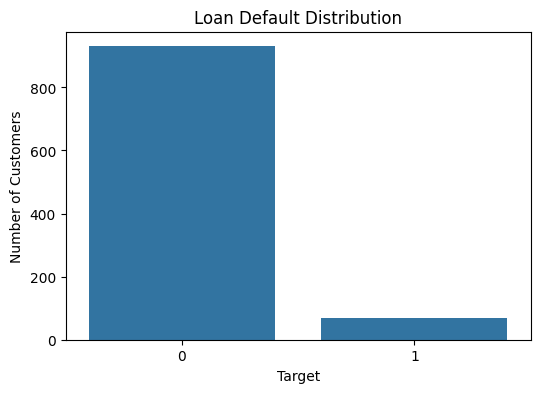

In [28]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=application_sample,
    x='TARGET'
)

plt.title('Loan Default Distribution')
plt.xlabel('Target')
plt.ylabel('Number of Customers')

plt.show()

In [29]:
print("Sample shape:", application_sample.shape)

Sample shape: (1000, 122)


In [30]:
print("Number of columns:", len(application_sample.columns))

Number of columns: 122


## 2. Dataset Structure and Feature Understanding

The application_train dataset contains 122 columns representing demographic,
financial, employment, family, housing, and application-related information.

The `TARGET` variable is the dependent variable:

- 0 = Customer did not default
- 1 = Customer defaulted

`SK_ID_CURR` is the unique identifier for the current loan application.

The remaining variables contain information that may help identify patterns
associated with loan default risk.

In [31]:
for i, column in enumerate(application_sample.columns, start=1):
    print(f"{i:3}. {column}")

  1. SK_ID_CURR
  2. TARGET
  3. NAME_CONTRACT_TYPE
  4. CODE_GENDER
  5. FLAG_OWN_CAR
  6. FLAG_OWN_REALTY
  7. CNT_CHILDREN
  8. AMT_INCOME_TOTAL
  9. AMT_CREDIT
 10. AMT_ANNUITY
 11. AMT_GOODS_PRICE
 12. NAME_TYPE_SUITE
 13. NAME_INCOME_TYPE
 14. NAME_EDUCATION_TYPE
 15. NAME_FAMILY_STATUS
 16. NAME_HOUSING_TYPE
 17. REGION_POPULATION_RELATIVE
 18. DAYS_BIRTH
 19. DAYS_EMPLOYED
 20. DAYS_REGISTRATION
 21. DAYS_ID_PUBLISH
 22. OWN_CAR_AGE
 23. FLAG_MOBIL
 24. FLAG_EMP_PHONE
 25. FLAG_WORK_PHONE
 26. FLAG_CONT_MOBILE
 27. FLAG_PHONE
 28. FLAG_EMAIL
 29. OCCUPATION_TYPE
 30. CNT_FAM_MEMBERS
 31. REGION_RATING_CLIENT
 32. REGION_RATING_CLIENT_W_CITY
 33. WEEKDAY_APPR_PROCESS_START
 34. HOUR_APPR_PROCESS_START
 35. REG_REGION_NOT_LIVE_REGION
 36. REG_REGION_NOT_WORK_REGION
 37. LIVE_REGION_NOT_WORK_REGION
 38. REG_CITY_NOT_LIVE_CITY
 39. REG_CITY_NOT_WORK_CITY
 40. LIVE_CITY_NOT_WORK_CITY
 41. ORGANIZATION_TYPE
 42. EXT_SOURCE_1
 43. EXT_SOURCE_2
 44. EXT_SOURCE_3
 45. APARTMENTS_AVG
 46

In [32]:
financial_columns = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE'
]

application_sample[financial_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,1000.0,167660.480655,90167.625149,31500.0,112500.000,144000.0,202500.00,765000.0
AMT_CREDIT,1000.0,595306.363500,388475.193497,47970.0,273584.250,516514.5,808650.00,2286211.5
AMT_ANNUITY,1000.0,27120.672000,14278.923334,4504.5,16603.875,25371.0,34103.25,116266.5
AMT_GOODS_PRICE,999.0,536198.198198,359636.247085,45000.0,238500.000,450000.0,679500.00,2250000.0


In [33]:
#The customer is requesting credit equal to 5× their income.
application_sample['CREDIT_INCOME_RATIO'] = (
    application_sample['AMT_CREDIT'] /
    application_sample['AMT_INCOME_TOTAL']
)

application_sample[
    ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'CREDIT_INCOME_RATIO']
].head()

,AMT_INCOME_TOTAL,AMT_CREDIT,CREDIT_INCOME_RATIO
0,202500.0,406597.5,2.007889
1,270000.0,1293502.5,4.790750
2,67500.0,135000.0,2.000000
3,135000.0,312682.5,2.316167
4,121500.0,513000.0,4.222222


In [34]:
application_sample.groupby('TARGET')['CREDIT_INCOME_RATIO'].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,930.0,3.892942,2.478726,0.285714,2.017387,3.167615,5.280334,15.193846
1,70.0,4.343352,4.349386,0.564343,2.142679,3.500800,5.474827,34.916667


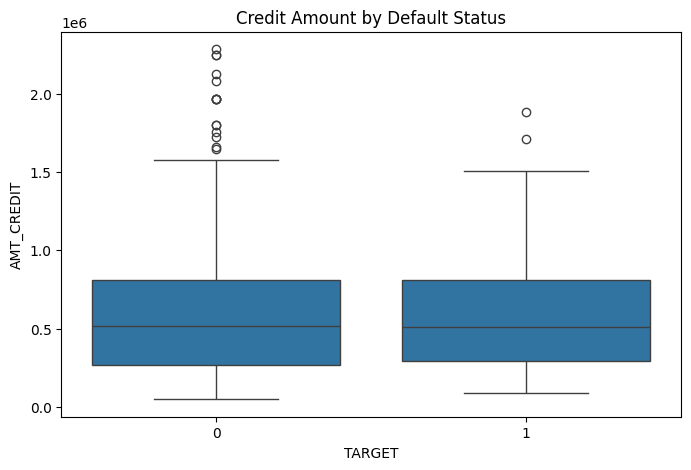

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=application_sample,
    x='TARGET',
    y='AMT_CREDIT'
)

plt.title('Credit Amount by Default Status')
plt.xlabel('TARGET')
plt.ylabel('AMT_CREDIT')

plt.show()

In [36]:
application_sample['CREDIT_INCOME_RATIO'] = (
    application_sample['AMT_CREDIT'] /
    application_sample['AMT_INCOME_TOTAL']
)

application_sample.groupby('TARGET')['CREDIT_INCOME_RATIO'].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,930.0,3.892942,2.478726,0.285714,2.017387,3.167615,5.280334,15.193846
1,70.0,4.343352,4.349386,0.564343,2.142679,3.500800,5.474827,34.916667


## 3. Bureau Credit History Analysis

The bureau dataset contains information about the customer's previous credits
reported by other financial institutions.

It is connected to the main application dataset through `SK_ID_CURR`.
Each customer may have multiple previous credit accounts.

In [37]:
bureau_sample = pd.read_csv(
    DATA_PATH + '/bureau.csv',
    nrows=5000
)

print("Bureau sample shape:", bureau_sample.shape)

Bureau sample shape: (5000, 17)


In [38]:
print("Number of columns:", len(bureau_sample.columns))

for i, column in enumerate(bureau_sample.columns, start=1):
    print(f"{i:3}. {column}")

Number of columns: 17
  1. SK_ID_CURR
  2. SK_ID_BUREAU
  3. CREDIT_ACTIVE
  4. CREDIT_CURRENCY
  5. DAYS_CREDIT
  6. CREDIT_DAY_OVERDUE
  7. DAYS_CREDIT_ENDDATE
  8. DAYS_ENDDATE_FACT
  9. AMT_CREDIT_MAX_OVERDUE
 10. CNT_CREDIT_PROLONG
 11. AMT_CREDIT_SUM
 12. AMT_CREDIT_SUM_DEBT
 13. AMT_CREDIT_SUM_LIMIT
 14. AMT_CREDIT_SUM_OVERDUE
 15. CREDIT_TYPE
 16. DAYS_CREDIT_UPDATE
 17. AMT_ANNUITY


In [39]:
bureau_sample.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [40]:
print("Bureau sample shape:", bureau_sample.shape)

Bureau sample shape: (5000, 17)


In [41]:
print("Number of columns:", len(bureau_sample.columns))

Number of columns: 17


In [42]:
bureau_sample['CREDIT_ACTIVE'].value_counts()

,count
CREDIT_ACTIVE,
Closed,3057
Active,1926
Sold,17


In [43]:
bureau_sample['CREDIT_ACTIVE'].value_counts(normalize=True) * 100

,proportion
CREDIT_ACTIVE,
Closed,61.14
Active,38.52
Sold,0.34


In [44]:
bureau_sample['CREDIT_TYPE'].value_counts().head(10)

,count
CREDIT_TYPE,
Consumer credit,3529
Credit card,1263
Car loan,95
Mortgage,68
Microloan,41
Loan for working capital replenishment,2
Loan for business development,1
Real estate loan,1


In [45]:
bureau_sample['CREDIT_DAY_OVERDUE'].describe()

,CREDIT_DAY_OVERDUE
count,5000.000000
mean,2.284000
std,65.585322
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2603.000000


In [46]:
bureau_sample['AMT_CREDIT_SUM_OVERDUE'].describe()

,AMT_CREDIT_SUM_OVERDUE
count,5000.000000
mean,121.249917
std,5535.355713
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,349428.060000


In [47]:
bureau_summary = bureau_sample.groupby('SK_ID_CURR').agg(
    PREVIOUS_CREDIT_COUNT=('SK_ID_BUREAU', 'count'),
    TOTAL_CREDIT=('AMT_CREDIT_SUM', 'sum'),
    TOTAL_DEBT=('AMT_CREDIT_SUM_DEBT', 'sum'),
    TOTAL_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    MAX_OVERDUE_DAYS=('CREDIT_DAY_OVERDUE', 'max')
).reset_index()

bureau_summary.head()

,SK_ID_CURR,PREVIOUS_CREDIT_COUNT,TOTAL_CREDIT,TOTAL_DEBT,TOTAL_OVERDUE,MAX_OVERDUE_DAYS
0,100568,7,834889.14,422599.50,0.0,0
1,101060,4,816575.49,408874.32,0.0,0
2,101562,7,2952412.92,1490476.50,0.0,0
3,101616,3,2295117.00,0.00,0.0,0
4,101724,2,354060.00,0.00,0.0,0


In [48]:
active_summary = (
    bureau_sample.assign(
        ACTIVE_CREDIT=lambda x: (x['CREDIT_ACTIVE'] == 'Active').astype(int)
    )
    .groupby('SK_ID_CURR')['ACTIVE_CREDIT']
    .sum()
    .reset_index(name='ACTIVE_CREDIT_COUNT')
)

active_summary.head()

,SK_ID_CURR,ACTIVE_CREDIT_COUNT
0,100568,3
1,101060,2
2,101562,5
3,101616,1
4,101724,1


In [49]:
bureau_balance_sample = pd.read_csv(
    DATA_PATH + '/bureau_balance.csv',
    nrows=5000
)

print("Bureau balance shape:", bureau_balance_sample.shape)

Bureau balance shape: (5000, 3)


In [50]:
  print("Number of columns:", len(bureau_balance_sample.columns))
print(bureau_balance_sample.head())

Number of columns: 3
   SK_ID_BUREAU  MONTHS_BALANCE STATUS
0       5715448               0      C
1       5715448              -1      C
2       5715448              -2      C
3       5715448              -3      C
4       5715448              -4      C


In [51]:
bureau_balance_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   SK_ID_BUREAU    5000 non-null   int64 
 1   MONTHS_BALANCE  5000 non-null   int64 
 2   STATUS          5000 non-null   object
dtypes: int64(2), object(1)
memory usage: 117.3+ KB


In [52]:
bureau_balance_sample['STATUS'].value_counts()

,count
STATUS,
C,2648
X,1173
0,1145
1,32
2,2


In [53]:
bureau_balance_sample['STATUS'].value_counts(normalize=True) * 100

,proportion
STATUS,
C,52.96
X,23.46
0,22.90
1,0.64
2,0.04


In [54]:
bureau_balance_sample['STATUS'].unique()

array(['C', '0', 'X', '1', '2'], dtype=object)

In [55]:
months_per_credit = (
    bureau_balance_sample
    .groupby('SK_ID_BUREAU')['MONTHS_BALANCE']
    .count()
)

months_per_credit.describe()

,MONTHS_BALANCE
count,141.000000
mean,35.460993
std,25.634663
min,4.000000
25%,16.000000
50%,28.000000
75%,48.000000
max,97.000000


In [56]:
previous_application_sample = pd.read_csv(
    DATA_PATH + '/previous_application.csv',
    nrows=5000
)

print("Previous application shape:", previous_application_sample.shape)

Previous application shape: (5000, 37)


In [57]:
  print("Number of columns:", len(previous_application_sample.columns))

Number of columns: 37


In [58]:
previous_application_sample.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
previous_application_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SK_ID_PREV                   5000 non-null   int64  
 1   SK_ID_CURR                   5000 non-null   int64  
 2   NAME_CONTRACT_TYPE           5000 non-null   object 
 3   AMT_ANNUITY                  4016 non-null   float64
 4   AMT_APPLICATION              5000 non-null   float64
 5   AMT_CREDIT                   5000 non-null   float64
 6   AMT_DOWN_PAYMENT             2746 non-null   float64
 7   AMT_GOODS_PRICE              4003 non-null   float64
 8   WEEKDAY_APPR_PROCESS_START   5000 non-null   object 
 9   HOUR_APPR_PROCESS_START      5000 non-null   int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  5000 non-null   object 
 11  NFLAG_LAST_APPL_IN_DAY       5000 non-null   int64  
 12  RATE_DOWN_PAYMENT            2746 non-null   float64
 13  RATE_INTEREST_PRIM

In [60]:
previous_application_sample['NAME_CONTRACT_STATUS'].value_counts()

,count
NAME_CONTRACT_STATUS,
Approved,3266
Refused,873
Canceled,761
Unused offer,100


In [61]:
previous_application_sample['NAME_CONTRACT_TYPE'].value_counts()

,count
NAME_CONTRACT_TYPE,
Consumer loans,2639
Cash loans,1793
Revolving loans,568


In [62]:
previous_application_sample['NAME_CLIENT_TYPE'].value_counts()

,count
NAME_CLIENT_TYPE,
Repeater,3537
New,1056
Refreshed,404
XNA,3


In [63]:
previous_application_sample[
    ['AMT_APPLICATION', 'AMT_CREDIT', 'AMT_ANNUITY',
     'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'CNT_PAYMENT']
].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_APPLICATION,5000.0,153059.043051,262113.694037,0.0,24480.00000,67500.00,151166.25000,2700000.00
AMT_CREDIT,5000.0,171441.810234,287561.347400,0.0,27910.12500,74812.50,172783.12500,3020760.00
AMT_ANNUITY,4016.0,14254.406366,13305.097684,0.0,5907.70125,10061.91,17787.18375,204635.79
AMT_DOWN_PAYMENT,2746.0,6261.035719,14854.389838,0.0,0.00000,1815.57,7929.00000,489600.00
AMT_GOODS_PRICE,4003.0,191180.418500,280231.187661,0.0,46908.00000,92601.00,188455.50000,2700000.00
CNT_PAYMENT,4016.0,14.376245,12.987804,0.0,6.00000,12.00,18.00000,60.00


In [64]:
pos_cash_sample = pd.read_csv(
    DATA_PATH + '/POS_CASH_balance.csv',
    nrows=5000
)

print("POS CASH shape:", pos_cash_sample.shape)
print("Number of columns:", len(pos_cash_sample.columns))

POS CASH shape: (5000, 8)
Number of columns: 8


In [65]:
pos_cash_sample.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [66]:
pos_cash_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SK_ID_PREV             5000 non-null   int64  
 1   SK_ID_CURR             5000 non-null   int64  
 2   MONTHS_BALANCE         5000 non-null   int64  
 3   CNT_INSTALMENT         4994 non-null   float64
 4   CNT_INSTALMENT_FUTURE  4994 non-null   float64
 5   NAME_CONTRACT_STATUS   5000 non-null   object 
 6   SK_DPD                 5000 non-null   int64  
 7   SK_DPD_DEF             5000 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 312.6+ KB


In [67]:
pos_cash_sample['SK_DPD'].describe()

,SK_DPD
count,5000.000000
mean,0.466800
std,16.656674
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1105.000000


In [68]:
pos_cash_sample['SK_DPD'].value_counts().head(10)

,count
SK_DPD,
0,4903
1,23
2,10
3,10
5,8
7,7
6,7
4,6
16,5


In [69]:
pos_cash_sample['SK_DPD_DEF'].describe()

,SK_DPD_DEF
count,5000.000000
mean,0.064000
std,0.714987
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,18.000000


In [70]:
pos_cash_sample['NAME_CONTRACT_STATUS'].value_counts()

,count
NAME_CONTRACT_STATUS,
Active,4606
Completed,360
Signed,28
Approved,3
Demand,2
Returned to the store,1


In [71]:
credit_card_sample = pd.read_csv(
    DATA_PATH + '/credit_card_balance.csv',
    nrows=5000
)

print("Credit Card shape:", credit_card_sample.shape)
print("Number of columns:", len(credit_card_sample.columns))

credit_card_sample.head()

Credit Card shape: (5000, 23)
Number of columns: 23


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [72]:
credit_card_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SK_ID_PREV                  5000 non-null   int64  
 1   SK_ID_CURR                  5000 non-null   int64  
 2   MONTHS_BALANCE              5000 non-null   int64  
 3   AMT_BALANCE                 5000 non-null   float64
 4   AMT_CREDIT_LIMIT_ACTUAL     5000 non-null   int64  
 5   AMT_DRAWINGS_ATM_CURRENT    3670 non-null   float64
 6   AMT_DRAWINGS_CURRENT        5000 non-null   float64
 7   AMT_DRAWINGS_OTHER_CURRENT  3670 non-null   float64
 8   AMT_DRAWINGS_POS_CURRENT    3670 non-null   float64
 9   AMT_INST_MIN_REGULARITY     5000 non-null   float64
 10  AMT_PAYMENT_CURRENT         3669 non-null   float64
 11  AMT_PAYMENT_TOTAL_CURRENT   5000 non-null   float64
 12  AMT_RECEIVABLE_PRINCIPAL    5000 non-null   float64
 13  AMT_RECIVABLE               5000 

In [73]:
credit_card_sample.isnull().sum()

,0
SK_ID_PREV,0
SK_ID_CURR,0
MONTHS_BALANCE,0
AMT_BALANCE,0
AMT_CREDIT_LIMIT_ACTUAL,0
AMT_DRAWINGS_ATM_CURRENT,1330
AMT_DRAWINGS_CURRENT,0
AMT_DRAWINGS_OTHER_CURRENT,1330
AMT_DRAWINGS_POS_CURRENT,1330
AMT_INST_MIN_REGULARITY,0


In [74]:
installments_sample = pd.read_csv(
    DATA_PATH + '/installments_payments.csv',
    nrows=5000
)

print("Installments shape:", installments_sample.shape)
print("Number of columns:", len(installments_sample.columns))

installments_sample.head()

Installments shape: (5000, 8)
Number of columns: 8


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [75]:
installments_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SK_ID_PREV              5000 non-null   int64  
 1   SK_ID_CURR              5000 non-null   int64  
 2   NUM_INSTALMENT_VERSION  5000 non-null   float64
 3   NUM_INSTALMENT_NUMBER   5000 non-null   int64  
 4   DAYS_INSTALMENT         5000 non-null   float64
 5   DAYS_ENTRY_PAYMENT      5000 non-null   float64
 6   AMT_INSTALMENT          5000 non-null   float64
 7   AMT_PAYMENT             5000 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 312.6 KB


In [76]:
installments_sample.isnull().sum()

,0
SK_ID_PREV,0
SK_ID_CURR,0
NUM_INSTALMENT_VERSION,0
NUM_INSTALMENT_NUMBER,0
DAYS_INSTALMENT,0
DAYS_ENTRY_PAYMENT,0
AMT_INSTALMENT,0
AMT_PAYMENT,0


In [77]:
installments_sample['PAYMENT_DELAY'] = (
    installments_sample['DAYS_ENTRY_PAYMENT']
    - installments_sample['DAYS_INSTALMENT']
)

In [78]:
installments_sample['PAYMENT_DELAY'].describe()

,PAYMENT_DELAY
count,5000.000000
mean,-8.599200
std,23.961081
min,-272.000000
25%,-14.000000
50%,-6.000000
75%,0.000000
max,1143.000000


In [79]:
installments_sample['PAYMENT_DIFFERENCE'] = (
    installments_sample['AMT_PAYMENT']
    - installments_sample['AMT_INSTALMENT']
)

In [80]:
installments_sample['PAYMENT_DIFFERENCE'].describe()

,PAYMENT_DIFFERENCE
count,5000.000000
mean,743.522859
std,26068.951045
min,-150925.500000
25%,0.000000
50%,0.000000
75%,0.000000
max,961972.155000


In [81]:
installments_sample['PAYMENT_RATIO'] = (
    installments_sample['AMT_PAYMENT']
    / installments_sample['AMT_INSTALMENT'].replace(0, np.nan)
)

In [82]:
installments_sample['PAYMENT_RATIO'].describe()

,PAYMENT_RATIO
count,5000.000000
mean,1.035654
std,1.769728
min,0.000003
25%,1.000000
50%,1.000000
75%,1.000000
max,94.526510


In [83]:
late_payment_count = (
    installments_sample
    .assign(IS_LATE=(
        installments_sample['PAYMENT_DELAY'] > 0
    ).astype(int))
    .groupby('SK_ID_CURR')['IS_LATE']
    .sum()
    .reset_index(name='LATE_PAYMENT_COUNT')
)

late_payment_count.head()

,SK_ID_CURR,LATE_PAYMENT_COUNT
0,100009,0
1,100012,0
2,100042,0
3,100100,0
4,100128,0


In [84]:
bureau_fe = bureau_sample.copy()

bureau_fe.shape

(5000, 17)

In [85]:
# Load Bureau sample again

bureau_sample = pd.read_csv(
    DATA_PATH + '/bureau.csv',
    nrows=5000
)

print("Bureau sample shape:", bureau_sample.shape)
bureau_sample.head()

Bureau sample shape: (5000, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [86]:
# Create a copy for feature engineering

bureau_fe = bureau_sample.copy()

print("Bureau FE shape:", bureau_fe.shape)

Bureau FE shape: (5000, 17)


In [87]:
bureau_fe = bureau_sample.copy()

print("Bureau FE shape:", bureau_fe.shape)

Bureau FE shape: (5000, 17)


In [88]:
# ==========================================
# BUREAU FEATURE ENGINEERING
# ==========================================

# Number of previous credits
bureau_fe['PREVIOUS_CREDIT_COUNT'] = (
    bureau_fe.groupby('SK_ID_CURR')['SK_ID_BUREAU']
    .transform('count')
)

# Total previous credit amount
bureau_fe['TOTAL_CREDIT'] = (
    bureau_fe.groupby('SK_ID_CURR')['AMT_CREDIT_SUM']
    .transform('sum')
)

# Total previous debt
bureau_fe['TOTAL_DEBT'] = (
    bureau_fe.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_DEBT']
    .transform('sum')
)

# Total overdue amount
bureau_fe['TOTAL_OVERDUE'] = (
    bureau_fe.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_OVERDUE']
    .transform('sum')
)

# Maximum overdue days
bureau_fe['MAX_OVERDUE_DAYS'] = (
    bureau_fe.groupby('SK_ID_CURR')['CREDIT_DAY_OVERDUE']
    .transform('max')
)

bureau_fe[
    [
        'SK_ID_CURR',
        'PREVIOUS_CREDIT_COUNT',
        'TOTAL_CREDIT',
        'TOTAL_DEBT',
        'TOTAL_OVERDUE',
        'MAX_OVERDUE_DAYS'
    ]
].head()

,SK_ID_CURR,PREVIOUS_CREDIT_COUNT,TOTAL_CREDIT,TOTAL_DEBT,TOTAL_OVERDUE,MAX_OVERDUE_DAYS
0,215354,7,3792750.3,284463.18,0.0,0
1,215354,7,3792750.3,284463.18,0.0,0
2,215354,7,3792750.3,284463.18,0.0,0
3,215354,7,3792750.3,284463.18,0.0,0
4,215354,7,3792750.3,284463.18,0.0,0


In [89]:
# ==========================================
# CREATE CUSTOMER-LEVEL BUREAU SUMMARY
# ==========================================

bureau_summary = (
    bureau_fe.groupby('SK_ID_CURR')
    .agg({
        'PREVIOUS_CREDIT_COUNT': 'max',
        'TOTAL_CREDIT': 'max',
        'TOTAL_DEBT': 'max',
        'TOTAL_OVERDUE': 'max',
        'MAX_OVERDUE_DAYS': 'max'
    })
    .reset_index()
)

print("Bureau summary shape:", bureau_summary.shape)

bureau_summary.head()

Bureau summary shape: (1004, 6)


,SK_ID_CURR,PREVIOUS_CREDIT_COUNT,TOTAL_CREDIT,TOTAL_DEBT,TOTAL_OVERDUE,MAX_OVERDUE_DAYS
0,100568,7,834889.14,422599.50,0.0,0
1,101060,4,816575.49,408874.32,0.0,0
2,101562,7,2952412.92,1490476.50,0.0,0
3,101616,3,2295117.00,0.00,0.0,0
4,101724,2,354060.00,0.00,0.0,0


In [90]:
print("Unique customers:", bureau_summary['SK_ID_CURR'].nunique())
print("Rows:", len(bureau_summary))

print("\nDuplicate customer IDs:")
print(bureau_summary['SK_ID_CURR'].duplicated().sum())

Unique customers: 1004
Rows: 1004

Duplicate customer IDs:
0


In [91]:
# ==========================================
# CREATE MAIN MODELING DATASET
# ==========================================

model_data = application_sample.copy()

print("Application data shape:", model_data.shape)

Application data shape: (1000, 123)


In [92]:
# ==========================================
# MERGE BUREAU FEATURES
# ==========================================

model_data = model_data.merge(
    bureau_summary,
    on='SK_ID_CURR',
    how='left'
)

print("After Bureau merge:", model_data.shape)

After Bureau merge: (1000, 128)


In [93]:
model_data[
    [
        'SK_ID_CURR',
        'PREVIOUS_CREDIT_COUNT',
        'TOTAL_CREDIT',
        'TOTAL_DEBT',
        'TOTAL_OVERDUE',
        'MAX_OVERDUE_DAYS',
        'TARGET'
    ]
].head()

,SK_ID_CURR,PREVIOUS_CREDIT_COUNT,TOTAL_CREDIT,TOTAL_DEBT,TOTAL_OVERDUE,MAX_OVERDUE_DAYS,TARGET
0,100002,NaN,NaN,NaN,NaN,NaN,1
1,100003,NaN,NaN,NaN,NaN,NaN,0
2,100004,NaN,NaN,NaN,NaN,NaN,0
3,100006,NaN,NaN,NaN,NaN,NaN,0
4,100007,NaN,NaN,NaN,NaN,NaN,0


In [94]:
print("After Bureau merge:", model_data.shape)

After Bureau merge: (1000, 128)


In [95]:
# ==========================================
# BUREAU BALANCE FEATURE ENGINEERING
# ==========================================

bureau_balance_fe = bureau_balance_sample.copy()

print("Bureau balance FE shape:", bureau_balance_fe.shape)

Bureau balance FE shape: (5000, 3)


In [96]:
# ==========================================
# LOAD BUREAU BALANCE SAMPLE
# ==========================================

bureau_balance_sample = pd.read_csv(
    DATA_PATH + '/bureau_balance.csv',
    nrows=5000
)

print("Bureau balance sample shape:", bureau_balance_sample.shape)
print("Number of columns:", len(bureau_balance_sample.columns))

bureau_balance_sample.head()

Bureau balance sample shape: (5000, 3)
Number of columns: 3


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [97]:
bureau_balance_fe['DELINQUENT_STATUS'] = (
    bureau_balance_fe['STATUS']
    .isin(['1', '2', '3', '4', '5'])
    .astype(int)
)

print(
    bureau_balance_fe['DELINQUENT_STATUS']
    .value_counts()
)


DELINQUENT_STATUS
0    4966
1      34
Name: count, dtype: int64


In [98]:
# ==========================================
# BUREAU BALANCE FEATURE ENGINEERING
# ==========================================

# Create customer-level summary
bureau_balance_fe = (
    bureau_balance_fe
    .groupby('SK_ID_BUREAU')
    .agg(
        MONTHS_BALANCE_COUNT=('MONTHS_BALANCE', 'count'),
        DELINQUENT_MONTHS=('DELINQUENT_STATUS', 'sum'),
        MAX_DELINQUENT_STATUS=('DELINQUENT_STATUS', 'max')
    )
    .reset_index()
)

print("Bureau Balance FE shape:", bureau_balance_fe.shape)

bureau_balance_fe.head()

Bureau Balance FE shape: (141, 4)


,SK_ID_BUREAU,MONTHS_BALANCE_COUNT,DELINQUENT_MONTHS,MAX_DELINQUENT_STATUS
0,5715448,27,0,0
1,5715449,12,0,0
2,5715451,26,0,0
3,5715452,33,0,0
4,5715453,38,0,0


In [99]:
bureau_balance_fe.describe()

,SK_ID_BUREAU,MONTHS_BALANCE_COUNT,DELINQUENT_MONTHS,MAX_DELINQUENT_STATUS
count,1.410000e+02,141.000000,141.000000,141.000000
mean,5.717952e+06,35.460993,0.241135,0.099291
std,1.375946e+03,25.634663,1.139553,0.300118
min,5.715448e+06,4.000000,0.000000,0.000000
25%,5.717364e+06,16.000000,0.000000,0.000000
50%,5.718509e+06,28.000000,0.000000,0.000000
75%,5.719024e+06,48.000000,0.000000,0.000000
max,5.719294e+06,97.000000,12.000000,1.000000


In [100]:
# ==========================================
# MERGE BUREAU BALANCE FEATURES WITH BUREAU
# ==========================================

bureau_fe = bureau_sample.copy()

bureau_fe = bureau_fe.merge(
    bureau_balance_fe,
    on='SK_ID_BUREAU',
    how='left'
)

print("Bureau after Bureau Balance merge:", bureau_fe.shape)

bureau_fe.head()

Bureau after Bureau Balance merge: (5000, 20)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,MONTHS_BALANCE_COUNT,DELINQUENT_MONTHS,MAX_DELINQUENT_STATUS
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN,NaN,NaN,NaN


In [101]:
# Check missing values created by the merge

bureau_fe[
    [
        'MONTHS_BALANCE_COUNT',
        'DELINQUENT_MONTHS',
        'MAX_DELINQUENT_STATUS'
    ]
].isnull().sum()

,0
MONTHS_BALANCE_COUNT,4867
DELINQUENT_MONTHS,4867
MAX_DELINQUENT_STATUS,4867


In [102]:
# Fill accounts that have no bureau-balance history

bureau_fe[
    [
        'MONTHS_BALANCE_COUNT',
        'DELINQUENT_MONTHS',
        'MAX_DELINQUENT_STATUS'
    ]
] = bureau_fe[
    [
        'MONTHS_BALANCE_COUNT',
        'DELINQUENT_MONTHS',
        'MAX_DELINQUENT_STATUS'
    ]
].fillna(0)

print("Missing values after filling:")
print(
    bureau_fe[
        [
            'MONTHS_BALANCE_COUNT',
            'DELINQUENT_MONTHS',
            'MAX_DELINQUENT_STATUS'
        ]
    ].isnull().sum()
)

Missing values after filling:
MONTHS_BALANCE_COUNT     0
DELINQUENT_MONTHS        0
MAX_DELINQUENT_STATUS    0
dtype: int64


In [103]:
# ==========================================
# CUSTOMER-LEVEL BUREAU FEATURE ENGINEERING
# ==========================================

bureau_customer = (
    bureau_fe
    .groupby('SK_ID_CURR')
    .agg(
        PREVIOUS_CREDIT_COUNT=('SK_ID_BUREAU', 'nunique'),

        TOTAL_CREDIT=('AMT_CREDIT_SUM', 'sum'),
        TOTAL_DEBT=('AMT_CREDIT_SUM_DEBT', 'sum'),
        TOTAL_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'sum'),

        MAX_OVERDUE_DAYS=('CREDIT_DAY_OVERDUE', 'max'),

        TOTAL_DELINQUENT_MONTHS=('DELINQUENT_MONTHS', 'sum'),
        MAX_DELINQUENT_STATUS=('MAX_DELINQUENT_STATUS', 'max'),

        TOTAL_CREDIT_HISTORY_MONTHS=('MONTHS_BALANCE_COUNT', 'sum')
    )
    .reset_index()
)

print("Customer-level Bureau shape:", bureau_customer.shape)

bureau_customer.head(20)

Customer-level Bureau shape: (1004, 9)


,SK_ID_CURR,PREVIOUS_CREDIT_COUNT,TOTAL_CREDIT,TOTAL_DEBT,TOTAL_OVERDUE,MAX_OVERDUE_DAYS,TOTAL_DELINQUENT_MONTHS,MAX_DELINQUENT_STATUS,TOTAL_CREDIT_HISTORY_MONTHS
0,100568,7,834889.14,422599.500,0.0,0,0.0,0.0,0.0
1,101060,4,816575.49,408874.320,0.0,0,0.0,0.0,0.0
2,101562,7,2952412.92,1490476.500,0.0,0,0.0,0.0,0.0
3,101616,3,2295117.00,0.000,0.0,0,0.0,0.0,0.0
4,101724,2,354060.00,0.000,0.0,0,0.0,0.0,0.0
5,102099,3,739683.00,525850.965,0.0,0,0.0,0.0,0.0
6,102617,18,2524208.40,923315.040,0.0,0,0.0,0.0,0.0
7,103173,6,627345.00,0.000,0.0,0,0.0,0.0,158.0
8,103953,7,1803217.50,696222.000,0.0,0,0.0,0.0,0.0
9,104166,10,7673634.18,1869007.500,0.0,0,0.0,0.0,0.0


In [104]:
print("Unique customers:", bureau_customer['SK_ID_CURR'].nunique())
print("Rows:", len(bureau_customer))

print("\nDuplicate customer IDs:")
print(bureau_customer['SK_ID_CURR'].duplicated().sum())

Unique customers: 1004
Rows: 1004

Duplicate customer IDs:
0


In [105]:
# ==========================================
# MERGE CUSTOMER-LEVEL BUREAU FEATURES
# ==========================================

model_data = model_data.merge(
    bureau_customer,
    on='SK_ID_CURR',
    how='left',
    suffixes=('', '_BUREAU')
)

print("After Bureau merge:", model_data.shape)

After Bureau merge: (1000, 136)


In [106]:
print("Customers with Bureau data:",
      model_data['PREVIOUS_CREDIT_COUNT'].notna().sum())

print("Customers without Bureau data:",
      model_data['PREVIOUS_CREDIT_COUNT'].isna().sum())

Customers with Bureau data: 1
Customers without Bureau data: 999


In [107]:
# Fill missing Bureau values for customers
# who have no previous Bureau credit history

bureau_features = [
    'PREVIOUS_CREDIT_COUNT',
    'TOTAL_CREDIT',
    'TOTAL_DEBT',
    'TOTAL_OVERDUE',
    'MAX_OVERDUE_DAYS',
    'TOTAL_DELINQUENT_MONTHS',
    'MAX_DELINQUENT_STATUS',
    'TOTAL_CREDIT_HISTORY_MONTHS'
]

model_data[bureau_features] = model_data[bureau_features].fillna(0)

In [108]:
print("Missing Bureau values:")
print(model_data[bureau_features].isnull().sum())

Missing Bureau values:
PREVIOUS_CREDIT_COUNT          0
TOTAL_CREDIT                   0
TOTAL_DEBT                     0
TOTAL_OVERDUE                  0
MAX_OVERDUE_DAYS               0
TOTAL_DELINQUENT_MONTHS        0
MAX_DELINQUENT_STATUS          0
TOTAL_CREDIT_HISTORY_MONTHS    0
dtype: int64


In [109]:
# ============================================================
# PREVIOUS APPLICATION FEATURE ENGINEERING
# ============================================================

previous_app_fe = previous_application_sample.copy()

print("Previous Application FE shape:", previous_app_fe.shape)

Previous Application FE shape: (5000, 37)


In [110]:
# ============================================================
# LOAD PREVIOUS APPLICATION DATA
# ============================================================

previous_application_sample = pd.read_csv(
    DATA_PATH + '/previous_application.csv',
    nrows=5000
)

print("Previous Application shape:", previous_application_sample.shape)
print("Number of columns:", len(previous_application_sample.columns))

previous_application_sample.head()

Previous Application shape: (5000, 37)
Number of columns: 37


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
print(previous_application_sample[
    [
        'SK_ID_PREV',
        'SK_ID_CURR',
        'NAME_CONTRACT_STATUS',
        'AMT_APPLICATION',
        'AMT_CREDIT',
        'AMT_DOWN_PAYMENT',
        'AMT_GOODS_PRICE',
        'CNT_PAYMENT'
    ]
].head())

   SK_ID_PREV  SK_ID_CURR NAME_CONTRACT_STATUS  AMT_APPLICATION  AMT_CREDIT  \
0     2030495      271877             Approved          17145.0     17145.0   
1     2802425      108129             Approved         607500.0    679671.0   
2     2523466      122040             Approved         112500.0    136444.5   
3     2819243      176158             Approved         450000.0    470790.0   
4     1784265      202054              Refused         337500.0    404055.0   

   AMT_DOWN_PAYMENT  AMT_GOODS_PRICE  CNT_PAYMENT  
0               0.0          17145.0         12.0  
1               NaN         607500.0         36.0  
2               NaN         112500.0         12.0  
3               NaN         450000.0         12.0  
4               NaN         337500.0         24.0  


In [112]:
# ============================================================
# PREVIOUS APPLICATION STATUS FLAGS
# ============================================================

previous_app_fe['APPROVED_FLAG'] = (
    previous_app_fe['NAME_CONTRACT_STATUS'] == 'Approved'
).astype(int)

previous_app_fe['REFUSED_FLAG'] = (
    previous_app_fe['NAME_CONTRACT_STATUS'] == 'Refused'
).astype(int)

previous_app_fe['CANCELED_FLAG'] = (
    previous_app_fe['NAME_CONTRACT_STATUS'] == 'Canceled'
).astype(int)

previous_app_fe['UNUSED_OFFER_FLAG'] = (
    previous_app_fe['NAME_CONTRACT_STATUS'] == 'Unused offer'
).astype(int)

print(
    previous_app_fe[
        [
            'NAME_CONTRACT_STATUS',
            'APPROVED_FLAG',
            'REFUSED_FLAG',
            'CANCELED_FLAG',
            'UNUSED_OFFER_FLAG'
        ]
    ].head(10)
)

  NAME_CONTRACT_STATUS  APPROVED_FLAG  REFUSED_FLAG  CANCELED_FLAG  \
0             Approved              1             0              0   
1             Approved              1             0              0   
2             Approved              1             0              0   
3             Approved              1             0              0   
4              Refused              0             1              0   
5             Approved              1             0              0   
6             Canceled              0             0              1   
7             Canceled              0             0              1   
8             Canceled              0             0              1   
9             Canceled              0             0              1   

   UNUSED_OFFER_FLAG  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  
5                  0  
6                  0  
7                  0  
8                  0  

CREDIT_APPLICATION_RATIO > 1 means the previous lender's AMT_CREDIT was greater than the requested AMT_APPLICATION.
DOWN_PAYMENT_RATIO has many NaN values because AMT_DOWN_PAYMENT is missing.
Rows with AMT_APPLICATION = 0 correctly produce NaN instead of an invalid division.
CREDIT_GOODS_RATIO is also NaN when AMT_GOODS_PRICE is missing.

In [113]:
# ============================================================
# PREVIOUS APPLICATION FINANCIAL RATIOS
# ============================================================

# Credit amount compared with requested application amount
previous_app_fe['CREDIT_APPLICATION_RATIO'] = (
    previous_app_fe['AMT_CREDIT'] /
    previous_app_fe['AMT_APPLICATION'].replace(0, float('nan'))
)

# Down payment compared with requested application amount
previous_app_fe['DOWN_PAYMENT_RATIO'] = (
    previous_app_fe['AMT_DOWN_PAYMENT'] /
    previous_app_fe['AMT_APPLICATION'].replace(0, float('nan'))
)

# Credit amount compared with goods price
previous_app_fe['CREDIT_GOODS_RATIO'] = (
    previous_app_fe['AMT_CREDIT'] /
    previous_app_fe['AMT_GOODS_PRICE'].replace(0, float('nan'))
)

# Check the newly created features
print(
    previous_app_fe[
        [
            'AMT_APPLICATION',
            'AMT_CREDIT',
            'AMT_DOWN_PAYMENT',
            'AMT_GOODS_PRICE',
            'CREDIT_APPLICATION_RATIO',
            'DOWN_PAYMENT_RATIO',
            'CREDIT_GOODS_RATIO'
        ]
    ].head(10)
)

   AMT_APPLICATION  AMT_CREDIT  AMT_DOWN_PAYMENT  AMT_GOODS_PRICE  \
0          17145.0     17145.0               0.0          17145.0   
1         607500.0    679671.0               NaN         607500.0   
2         112500.0    136444.5               NaN         112500.0   
3         450000.0    470790.0               NaN         450000.0   
4         337500.0    404055.0               NaN         337500.0   
5         315000.0    340573.5               NaN         315000.0   
6              0.0         0.0               NaN              NaN   
7              0.0         0.0               NaN              NaN   
8              0.0         0.0               NaN              NaN   
9              0.0         0.0               NaN              NaN   

   CREDIT_APPLICATION_RATIO  DOWN_PAYMENT_RATIO  CREDIT_GOODS_RATIO  
0                  1.000000                 0.0            1.000000  
1                  1.118800                 NaN            1.118800  
2                  1.212840   

In [114]:
# ============================================================
# PREVIOUS APPLICATION CUSTOMER-LEVEL AGGREGATION
# ============================================================

previous_app_customer = (
    previous_app_fe
    .groupby('SK_ID_CURR')
    .agg(
        TOTAL_PREVIOUS_APPLICATIONS=('SK_ID_PREV', 'nunique'),

        TOTAL_APPROVED_APPLICATIONS=('APPROVED_FLAG', 'sum'),

        TOTAL_REFUSED_APPLICATIONS=('REFUSED_FLAG', 'sum'),

        TOTAL_CANCELED_APPLICATIONS=('CANCELED_FLAG', 'sum'),

        TOTAL_UNUSED_OFFERS=('UNUSED_OFFER_FLAG', 'sum'),

        TOTAL_APPLICATION_AMOUNT=('AMT_APPLICATION', 'sum'),

        TOTAL_PREVIOUS_CREDIT=('AMT_CREDIT', 'sum'),

        AVERAGE_APPLICATION_AMOUNT=('AMT_APPLICATION', 'mean'),

        AVERAGE_CREDIT_AMOUNT=('AMT_CREDIT', 'mean'),

        TOTAL_DOWN_PAYMENT=('AMT_DOWN_PAYMENT', 'sum'),

        AVERAGE_CNT_PAYMENT=('CNT_PAYMENT', 'mean')
    )
    .reset_index()
)

print("Previous Application Customer-Level Shape:",
      previous_app_customer.shape)

print("\nFirst 5 rows:")
print(previous_app_customer.head())

Previous Application Customer-Level Shape: (4900, 12)

First 5 rows:
   SK_ID_CURR  TOTAL_PREVIOUS_APPLICATIONS  TOTAL_APPROVED_APPLICATIONS  \
0      100067                            1                            0   
1      100077                            1                            0   
2      100124                            1                            1   
3      100151                            1                            1   
4      100201                            1                            1   

   TOTAL_REFUSED_APPLICATIONS  TOTAL_CANCELED_APPLICATIONS  \
0                           1                            0   
1                           1                            0   
2                           0                            0   
3                           0                            0   
4                           0                            0   

   TOTAL_UNUSED_OFFERS  TOTAL_APPLICATION_AMOUNT  TOTAL_PREVIOUS_CREDIT  \
0                    0          

In [115]:
# ============================================================
# APPROVAL AND REFUSAL RATES
# ============================================================

previous_app_customer['APPROVAL_RATE'] = (
    previous_app_customer['TOTAL_APPROVED_APPLICATIONS'] /
    previous_app_customer['TOTAL_PREVIOUS_APPLICATIONS']
)

previous_app_customer['REFUSAL_RATE'] = (
    previous_app_customer['TOTAL_REFUSED_APPLICATIONS'] /
    previous_app_customer['TOTAL_PREVIOUS_APPLICATIONS']
)

# Check the results
print(
    previous_app_customer[
        [
            'SK_ID_CURR',
            'TOTAL_PREVIOUS_APPLICATIONS',
            'TOTAL_APPROVED_APPLICATIONS',
            'TOTAL_REFUSED_APPLICATIONS',
            'APPROVAL_RATE',
            'REFUSAL_RATE'
        ]
    ].head(10)
)

   SK_ID_CURR  TOTAL_PREVIOUS_APPLICATIONS  TOTAL_APPROVED_APPLICATIONS  \
0      100067                            1                            0   
1      100077                            1                            0   
2      100124                            1                            1   
3      100151                            1                            1   
4      100201                            1                            1   
5      100279                            1                            0   
6      100281                            1                            1   
7      100307                            1                            0   
8      100373                            1                            1   
9      100422                            1                            0   

   TOTAL_REFUSED_APPLICATIONS  APPROVAL_RATE  REFUSAL_RATE  
0                           1            0.0           1.0  
1                           1            0.0        

In [116]:
# ============================================================
# VALIDATE PREVIOUS APPLICATION CUSTOMER DATA
# ============================================================

print("Unique customers:",
      previous_app_customer['SK_ID_CURR'].nunique())

print("Rows:",
      len(previous_app_customer))

print("Duplicate customer IDs:",
      previous_app_customer['SK_ID_CURR'].duplicated().sum())

Unique customers: 4900
Rows: 4900
Duplicate customer IDs: 0


In [117]:
# ============================================================
# MERGE PREVIOUS APPLICATION FEATURES INTO MODEL DATA
# ============================================================

model_data = model_data.merge(
    previous_app_customer,
    on='SK_ID_CURR',
    how='left',
    suffixes=('', '_PREVIOUS_APP')
)

print("Model data shape after Previous Application merge:")
print(model_data.shape)

Model data shape after Previous Application merge:
(1000, 149)


In [118]:
# ============================================================
# FILL MISSING PREVIOUS APPLICATION FEATURES
# ============================================================

previous_app_features = [
    'TOTAL_PREVIOUS_APPLICATIONS',
    'TOTAL_APPROVED_APPLICATIONS',
    'TOTAL_REFUSED_APPLICATIONS',
    'TOTAL_CANCELED_APPLICATIONS',
    'TOTAL_UNUSED_OFFERS',
    'TOTAL_APPLICATION_AMOUNT',
    'TOTAL_PREVIOUS_CREDIT',
    'AVERAGE_APPLICATION_AMOUNT',
    'AVERAGE_CREDIT_AMOUNT',
    'TOTAL_DOWN_PAYMENT',
    'AVERAGE_CNT_PAYMENT',
    'APPROVAL_RATE',
    'REFUSAL_RATE'
]

model_data[previous_app_features] = (
    model_data[previous_app_features].fillna(0)
)

print("Missing values after filling:")
print(model_data[previous_app_features].isnull().sum())

Missing values after filling:
TOTAL_PREVIOUS_APPLICATIONS    0
TOTAL_APPROVED_APPLICATIONS    0
TOTAL_REFUSED_APPLICATIONS     0
TOTAL_CANCELED_APPLICATIONS    0
TOTAL_UNUSED_OFFERS            0
TOTAL_APPLICATION_AMOUNT       0
TOTAL_PREVIOUS_CREDIT          0
AVERAGE_APPLICATION_AMOUNT     0
AVERAGE_CREDIT_AMOUNT          0
TOTAL_DOWN_PAYMENT             0
AVERAGE_CNT_PAYMENT            0
APPROVAL_RATE                  0
REFUSAL_RATE                   0
dtype: int64


In [119]:
# ============================================================
# CHECK PREVIOUS APPLICATION FEATURES AFTER MERGE
# ============================================================

previous_app_features = [
    'TOTAL_PREVIOUS_APPLICATIONS',
    'TOTAL_APPROVED_APPLICATIONS',
    'TOTAL_REFUSED_APPLICATIONS',
    'TOTAL_CANCELED_APPLICATIONS',
    'TOTAL_UNUSED_OFFERS',
    'TOTAL_APPLICATION_AMOUNT',
    'TOTAL_PREVIOUS_CREDIT',
    'AVERAGE_APPLICATION_AMOUNT',
    'AVERAGE_CREDIT_AMOUNT',
    'TOTAL_DOWN_PAYMENT',
    'AVERAGE_CNT_PAYMENT',
    'APPROVAL_RATE',
    'REFUSAL_RATE'
]

model_data[previous_app_features] = (
    model_data[previous_app_features].fillna(0)
)

print("Missing values after filling:")
print(model_data[previous_app_features].isnull().sum())

Missing values after filling:
TOTAL_PREVIOUS_APPLICATIONS    0
TOTAL_APPROVED_APPLICATIONS    0
TOTAL_REFUSED_APPLICATIONS     0
TOTAL_CANCELED_APPLICATIONS    0
TOTAL_UNUSED_OFFERS            0
TOTAL_APPLICATION_AMOUNT       0
TOTAL_PREVIOUS_CREDIT          0
AVERAGE_APPLICATION_AMOUNT     0
AVERAGE_CREDIT_AMOUNT          0
TOTAL_DOWN_PAYMENT             0
AVERAGE_CNT_PAYMENT            0
APPROVAL_RATE                  0
REFUSAL_RATE                   0
dtype: int64


In [120]:
# ============================================================
# LOAD POS CASH BALANCE DATA
# ============================================================

pos_cash_sample = pd.read_csv(
    DATA_PATH + '/POS_CASH_balance.csv',
    nrows=5000
)

print("POS CASH shape:", pos_cash_sample.shape)
print("Number of columns:", len(pos_cash_sample.columns))

pos_cash_sample.head()

POS CASH shape: (5000, 8)
Number of columns: 8


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [121]:
# ============================================================
# POS CASH — DELINQUENCY FEATURES
# ============================================================

pos_cash_fe = pos_cash_sample.copy()

# Any past-due record
pos_cash_fe['DPD_FLAG'] = (
    pos_cash_fe['SK_DPD'] > 0
).astype(int)

# Any defined/default past-due record
pos_cash_fe['DPD_DEF_FLAG'] = (
    pos_cash_fe['SK_DPD_DEF'] > 0
).astype(int)

print(
    pos_cash_fe[
        [
            'SK_ID_CURR',
            'SK_DPD',
            'SK_DPD_DEF',
            'DPD_FLAG',
            'DPD_DEF_FLAG'
        ]
    ].head(10)
)

   SK_ID_CURR  SK_DPD  SK_DPD_DEF  DPD_FLAG  DPD_DEF_FLAG
0      182943       0           0         0             0
1      367990       0           0         0             0
2      397406       0           0         0             0
3      269225       0           0         0             0
4      334279       0           0         0             0
5      342166       0           0         0             0
6      204376       0           0         0             0
7      153211       0           0         0             0
8      112740       0           0         0             0
9      274851       0           0         0             0


In [122]:
# ============================================================
# POS CASH — CONTRACT STATUS FLAGS
# ============================================================

pos_cash_fe['ACTIVE_FLAG'] = (
    pos_cash_fe['NAME_CONTRACT_STATUS'] == 'Active'
).astype(int)

pos_cash_fe['COMPLETED_FLAG'] = (
    pos_cash_fe['NAME_CONTRACT_STATUS'] == 'Completed'
).astype(int)

print(
    pos_cash_fe[
        [
            'NAME_CONTRACT_STATUS',
            'ACTIVE_FLAG',
            'COMPLETED_FLAG'
        ]
    ].head(10)
)

  NAME_CONTRACT_STATUS  ACTIVE_FLAG  COMPLETED_FLAG
0               Active            1               0
1               Active            1               0
2               Active            1               0
3               Active            1               0
4               Active            1               0
5               Active            1               0
6               Active            1               0
7               Active            1               0
8               Active            1               0
9               Active            1               0


In [123]:
# ============================================================
# POS CASH — CUSTOMER-LEVEL AGGREGATION
# ============================================================

pos_cash_customer = (
    pos_cash_fe
    .groupby('SK_ID_CURR')
    .agg(
        TOTAL_POS_CASH_RECORDS=('SK_ID_PREV', 'count'),
        TOTAL_POS_CASH_LOANS=('SK_ID_PREV', 'nunique'),

        TOTAL_ACTIVE_LOANS=('ACTIVE_FLAG', 'sum'),
        TOTAL_COMPLETED_LOANS=('COMPLETED_FLAG', 'sum'),

        MAX_DPD=('SK_DPD', 'max'),
        TOTAL_DPD=('SK_DPD', 'sum'),
        DPD_RECORD_COUNT=('DPD_FLAG', 'sum'),

        MAX_DPD_DEF=('SK_DPD_DEF', 'max'),
        TOTAL_DPD_DEF=('SK_DPD_DEF', 'sum'),
        DPD_DEF_RECORD_COUNT=('DPD_DEF_FLAG', 'sum'),

        AVERAGE_INSTALLMENTS=('CNT_INSTALMENT', 'mean'),
        AVERAGE_FUTURE_INSTALLMENTS=('CNT_INSTALMENT_FUTURE', 'mean')
    )
    .reset_index()
)

print("POS CASH Customer-Level Shape:",
      pos_cash_customer.shape)

print("\nFirst 5 rows:")
print(pos_cash_customer.head())

POS CASH Customer-Level Shape: (4831, 13)

First 5 rows:
   SK_ID_CURR  TOTAL_POS_CASH_RECORDS  TOTAL_POS_CASH_LOANS  \
0      100028                       1                     1   
1      100187                       1                     1   
2      100223                       1                     1   
3      100292                       1                     1   
4      100442                       1                     1   

   TOTAL_ACTIVE_LOANS  TOTAL_COMPLETED_LOANS  MAX_DPD  TOTAL_DPD  \
0                   1                      0        0          0   
1                   1                      0        0          0   
2                   1                      0        0          0   
3                   0                      1        0          0   
4                   1                      0        0          0   

   DPD_RECORD_COUNT  MAX_DPD_DEF  TOTAL_DPD_DEF  DPD_DEF_RECORD_COUNT  \
0                 0            0              0                     0   
1        

In [124]:
# ============================================================
# VALIDATE POS CASH CUSTOMER DATA
# ============================================================

print(
    "Unique customers:",
    pos_cash_customer['SK_ID_CURR'].nunique()
)

print(
    "Rows:",
    len(pos_cash_customer)
)

print(
    "Duplicate customer IDs:",
    pos_cash_customer['SK_ID_CURR'].duplicated().sum()
)

Unique customers: 4831
Rows: 4831
Duplicate customer IDs: 0


In [125]:
# ============================================================
# MERGE POS CASH FEATURES INTO MODEL DATA
# ============================================================

model_data = model_data.merge(
    pos_cash_customer,
    on='SK_ID_CURR',
    how='left',
    suffixes=('', '_POS_CASH')
)

print("Model data shape after POS CASH merge:")
print(model_data.shape)


Model data shape after POS CASH merge:
(1000, 161)


In [126]:
# ============================================================
# FILL MISSING POS CASH FEATURES
# ============================================================

pos_cash_features = [
    'TOTAL_POS_CASH_RECORDS',
    'TOTAL_POS_CASH_LOANS',
    'TOTAL_ACTIVE_LOANS',
    'TOTAL_COMPLETED_LOANS',
    'MAX_DPD',
    'TOTAL_DPD',
    'DPD_RECORD_COUNT',
    'MAX_DPD_DEF',
    'TOTAL_DPD_DEF',
    'DPD_DEF_RECORD_COUNT',
    'AVERAGE_INSTALLMENTS',
    'AVERAGE_FUTURE_INSTALLMENTS'
]

model_data[pos_cash_features] = (
    model_data[pos_cash_features].fillna(0)
)

print("Missing values after filling:")
print(model_data[pos_cash_features].isnull().sum())

Missing values after filling:
TOTAL_POS_CASH_RECORDS         0
TOTAL_POS_CASH_LOANS           0
TOTAL_ACTIVE_LOANS             0
TOTAL_COMPLETED_LOANS          0
MAX_DPD                        0
TOTAL_DPD                      0
DPD_RECORD_COUNT               0
MAX_DPD_DEF                    0
TOTAL_DPD_DEF                  0
DPD_DEF_RECORD_COUNT           0
AVERAGE_INSTALLMENTS           0
AVERAGE_FUTURE_INSTALLMENTS    0
dtype: int64


In [127]:
# ============================================================
# LOAD CREDIT CARD BALANCE DATA
# ============================================================

credit_card_sample = pd.read_csv(
    DATA_PATH + '/credit_card_balance.csv',
    nrows=5000
)

print("Credit Card shape:", credit_card_sample.shape)
print("Number of columns:", len(credit_card_sample.columns))

credit_card_sample.head()

Credit Card shape: (5000, 23)
Number of columns: 23


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [128]:
# ============================================================
# CREDIT CARD — FEATURE ENGINEERING
# ============================================================

credit_card_fe = credit_card_sample.copy()

# Any overdue/delinquency
credit_card_fe['DPD_FLAG'] = (
    credit_card_fe['SK_DPD'] > 0
).astype(int)

# Any defined/default delinquency
credit_card_fe['DPD_DEF_FLAG'] = (
    credit_card_fe['SK_DPD_DEF'] > 0
).astype(int)

print(
    credit_card_fe[
        [
            'SK_ID_CURR',
            'SK_DPD',
            'SK_DPD_DEF',
            'DPD_FLAG',
            'DPD_DEF_FLAG'
        ]
    ].head(10)
)

   SK_ID_CURR  SK_DPD  SK_DPD_DEF  DPD_FLAG  DPD_DEF_FLAG
0      378907       0           0         0             0
1      363914       0           0         0             0
2      371185       0           0         0             0
3      337855       0           0         0             0
4      126868       0           0         0             0
5      380010       7           0         1             0
6      171320       0           0         0             0
7      118650       0           0         0             0
8      367360       0           0         0             0
9      203885       0           0         0             0


In [129]:
# ============================================================
# CREDIT CARD — CREDIT UTILIZATION
# ============================================================

credit_card_fe['CREDIT_UTILIZATION'] = (
    credit_card_fe['AMT_BALANCE'] /
    credit_card_fe['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, float('nan'))
)

print(
    credit_card_fe[
        [
            'AMT_BALANCE',
            'AMT_CREDIT_LIMIT_ACTUAL',
            'CREDIT_UTILIZATION'
        ]
    ].head(10)
)

   AMT_BALANCE  AMT_CREDIT_LIMIT_ACTUAL  CREDIT_UTILIZATION
0       56.970                   135000            0.000422
1    63975.555                    45000            1.421679
2    31815.225                   450000            0.070700
3   236572.110                   225000            1.051432
4   453919.455                   450000            1.008710
5    82903.815                   270000            0.307051
6   353451.645                   585000            0.604191
7    47962.125                    45000            1.065825
8   291543.075                   292500            0.996728
9   201261.195                   225000            0.894494


In [130]:
  # ============================================================
# CREDIT CARD — CUSTOMER-LEVEL AGGREGATION
# ============================================================

credit_card_customer = (
    credit_card_fe
    .groupby('SK_ID_CURR')
    .agg(
        TOTAL_CREDIT_CARD_RECORDS=('SK_ID_PREV', 'count'),
        TOTAL_CREDIT_CARD_LOANS=('SK_ID_PREV', 'nunique'),

        AVERAGE_CREDIT_CARD_BALANCE=('AMT_BALANCE', 'mean'),
        MAX_CREDIT_CARD_BALANCE=('AMT_BALANCE', 'max'),

        AVERAGE_CREDIT_LIMIT=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
        MAX_CREDIT_LIMIT=('AMT_CREDIT_LIMIT_ACTUAL', 'max'),

        AVERAGE_CREDIT_UTILIZATION=('CREDIT_UTILIZATION', 'mean'),
        MAX_CREDIT_UTILIZATION=('CREDIT_UTILIZATION', 'max'),

        TOTAL_DRAWINGS=('AMT_DRAWINGS_CURRENT', 'sum'),
        AVERAGE_DRAWINGS=('AMT_DRAWINGS_CURRENT', 'mean'),

        TOTAL_PAYMENTS=('AMT_PAYMENT_TOTAL_CURRENT', 'sum'),
        AVERAGE_PAYMENTS=('AMT_PAYMENT_TOTAL_CURRENT', 'mean'),

        MAX_DPD=('SK_DPD', 'max'),
        TOTAL_DPD=('SK_DPD', 'sum'),
        DPD_RECORD_COUNT=('DPD_FLAG', 'sum'),

        MAX_DPD_DEF=('SK_DPD_DEF', 'max'),
        TOTAL_DPD_DEF=('SK_DPD_DEF', 'sum'),
        DPD_DEF_RECORD_COUNT=('DPD_DEF_FLAG', 'sum')
    )
    .reset_index()
)

print("Credit Card Customer-Level Shape:",
      credit_card_customer.shape)

print("\nFirst 5 rows:")
print(credit_card_customer.head())

Credit Card Customer-Level Shape: (4990, 19)

First 5 rows:
   SK_ID_CURR  TOTAL_CREDIT_CARD_RECORDS  TOTAL_CREDIT_CARD_LOANS  \
0      100048                          1                        1   
1      100059                          1                        1   
2      100135                          1                        1   
3      100169                          1                        1   
4      100187                          1                        1   

   AVERAGE_CREDIT_CARD_BALANCE  MAX_CREDIT_CARD_BALANCE  AVERAGE_CREDIT_LIMIT  \
0                      27302.4                  27302.4              225000.0   
1                          0.0                      0.0                   0.0   
2                          0.0                      0.0               90000.0   
3                          0.0                      0.0              405000.0   
4                          0.0                      0.0               90000.0   

   MAX_CREDIT_LIMIT  AVERAGE_CREDIT_UT

In [131]:
# ============================================================
# VALIDATE CREDIT CARD CUSTOMER DATA
# ============================================================

print(
    "Unique customers:",
    credit_card_customer['SK_ID_CURR'].nunique()
)

print(
    "Rows:",
    len(credit_card_customer)
)

print(
    "Duplicate customer IDs:",
    credit_card_customer['SK_ID_CURR'].duplicated().sum()
)

Unique customers: 4990
Rows: 4990
Duplicate customer IDs: 0


In [132]:
# ============================================================
# MERGE CREDIT CARD FEATURES INTO MODEL DATA
# ============================================================

model_data = model_data.merge(
    credit_card_customer,
    on='SK_ID_CURR',
    how='left',
    suffixes=('', '_CREDIT_CARD')
)

print("Model data shape after Credit Card merge:")
print(model_data.shape)


Model data shape after Credit Card merge:
(1000, 179)


In [133]:
# ============================================================
# FILL MISSING CREDIT CARD FEATURES
# ============================================================

credit_card_features = [
    'TOTAL_CREDIT_CARD_RECORDS',
    'TOTAL_CREDIT_CARD_LOANS',
    'AVERAGE_CREDIT_CARD_BALANCE',
    'MAX_CREDIT_CARD_BALANCE',
    'AVERAGE_CREDIT_LIMIT',
    'MAX_CREDIT_LIMIT',
    'AVERAGE_CREDIT_UTILIZATION',
    'MAX_CREDIT_UTILIZATION',
    'TOTAL_DRAWINGS',
    'AVERAGE_DRAWINGS',
    'TOTAL_PAYMENTS',
    'AVERAGE_PAYMENTS',
    'MAX_DPD',
    'TOTAL_DPD',
    'DPD_RECORD_COUNT',
    'MAX_DPD_DEF',
    'TOTAL_DPD_DEF',
    'DPD_DEF_RECORD_COUNT'
]

model_data[credit_card_features] = (
    model_data[credit_card_features].fillna(0)
)

print("Missing values after filling:")
print(model_data[credit_card_features].isnull().sum())

Missing values after filling:
TOTAL_CREDIT_CARD_RECORDS      0
TOTAL_CREDIT_CARD_LOANS        0
AVERAGE_CREDIT_CARD_BALANCE    0
MAX_CREDIT_CARD_BALANCE        0
AVERAGE_CREDIT_LIMIT           0
MAX_CREDIT_LIMIT               0
AVERAGE_CREDIT_UTILIZATION     0
MAX_CREDIT_UTILIZATION         0
TOTAL_DRAWINGS                 0
AVERAGE_DRAWINGS               0
TOTAL_PAYMENTS                 0
AVERAGE_PAYMENTS               0
MAX_DPD                        0
TOTAL_DPD                      0
DPD_RECORD_COUNT               0
MAX_DPD_DEF                    0
TOTAL_DPD_DEF                  0
DPD_DEF_RECORD_COUNT           0
dtype: int64


In [134]:
# ============================================================
# LOAD INSTALLMENTS PAYMENTS DATA
# ============================================================

installments_sample = pd.read_csv(
    DATA_PATH + '/installments_payments.csv',
    nrows=5000
)

print("Installments shape:", installments_sample.shape)
print("Number of columns:", len(installments_sample.columns))

installments_sample.head()

Installments shape: (5000, 8)
Number of columns: 8


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [135]:
# ============================================================
# INSTALLMENTS PAYMENTS — FEATURE ENGINEERING
# ============================================================

installments_fe = installments_sample.copy()

# Difference between actual payment and scheduled installment
installments_fe['PAYMENT_DIFFERENCE'] = (
    installments_fe['AMT_PAYMENT'] -
    installments_fe['AMT_INSTALMENT']
)

# Payment delay in days
# Positive value = payment made after scheduled date
installments_fe['PAYMENT_DELAY'] = (
    installments_fe['DAYS_ENTRY_PAYMENT'] -
    installments_fe['DAYS_INSTALMENT']
)

# Late payment flag
installments_fe['LATE_PAYMENT_FLAG'] = (
    installments_fe['PAYMENT_DELAY'] > 0
).astype(int)

# Underpayment flag
installments_fe['UNDERPAYMENT_FLAG'] = (
    installments_fe['AMT_PAYMENT'] <
    installments_fe['AMT_INSTALMENT']
).astype(int)

print(
    installments_fe[
        [
            'SK_ID_CURR',
            'AMT_INSTALMENT',
            'AMT_PAYMENT',
            'PAYMENT_DIFFERENCE',
            'DAYS_INSTALMENT',
            'DAYS_ENTRY_PAYMENT',
            'PAYMENT_DELAY',
            'LATE_PAYMENT_FLAG',
            'UNDERPAYMENT_FLAG'
        ]
    ].head(10)
)

   SK_ID_CURR  AMT_INSTALMENT  AMT_PAYMENT  PAYMENT_DIFFERENCE  \
0      161674        6948.360     6948.360               0.000   
1      151639        1716.525     1716.525               0.000   
2      193053       25425.000    25425.000               0.000   
3      199697       24350.130    24350.130               0.000   
4      167756        2165.040     2160.585              -4.455   
5      164489        5970.375     5970.375               0.000   
6      184693       29432.295    29432.295               0.000   
7      111420       17862.165    17862.165               0.000   
8      112102          70.740       70.740               0.000   
9      109741       14308.470    14308.470               0.000   

   DAYS_INSTALMENT  DAYS_ENTRY_PAYMENT  PAYMENT_DELAY  LATE_PAYMENT_FLAG  \
0          -1180.0             -1187.0           -7.0                  0   
1          -2156.0             -2156.0            0.0                  0   
2            -63.0               -63.0       

In [136]:
# ============================================================
# INSTALLMENTS PAYMENTS — CUSTOMER-LEVEL AGGREGATION
# ============================================================

installments_customer = (
    installments_fe
    .groupby('SK_ID_CURR')
    .agg(
        TOTAL_INSTALLMENT_RECORDS=('SK_ID_PREV', 'count'),
        TOTAL_INSTALLMENT_LOANS=('SK_ID_PREV', 'nunique'),

        TOTAL_INSTALLMENT_AMOUNT=('AMT_INSTALMENT', 'sum'),
        TOTAL_PAYMENT_AMOUNT=('AMT_PAYMENT', 'sum'),

        AVERAGE_INSTALLMENT_AMOUNT=('AMT_INSTALMENT', 'mean'),
        AVERAGE_PAYMENT_AMOUNT=('AMT_PAYMENT', 'mean'),

        TOTAL_PAYMENT_DIFFERENCE=('PAYMENT_DIFFERENCE', 'sum'),
        AVERAGE_PAYMENT_DIFFERENCE=('PAYMENT_DIFFERENCE', 'mean'),

        MAX_PAYMENT_DELAY=('PAYMENT_DELAY', 'max'),
        TOTAL_PAYMENT_DELAY=('PAYMENT_DELAY', 'sum'),
        AVERAGE_PAYMENT_DELAY=('PAYMENT_DELAY', 'mean'),

        TOTAL_LATE_PAYMENTS=('LATE_PAYMENT_FLAG', 'sum'),
        TOTAL_UNDERPAYMENTS=('UNDERPAYMENT_FLAG', 'sum')
    )
    .reset_index()
)

print("Installments Customer-Level Shape:",
      installments_customer.shape)

print("\nFirst 5 rows:")
print(installments_customer.head())

Installments Customer-Level Shape: (4660, 14)

First 5 rows:
   SK_ID_CURR  TOTAL_INSTALLMENT_RECORDS  TOTAL_INSTALLMENT_LOANS  \
0      100009                          1                        1   
1      100012                          1                        1   
2      100042                          1                        1   
3      100100                          1                        1   
4      100128                          1                        1   

   TOTAL_INSTALLMENT_AMOUNT  TOTAL_PAYMENT_AMOUNT  AVERAGE_INSTALLMENT_AMOUNT  \
0                  8821.260              8821.260                    8821.260   
1                  5242.860              5242.860                    5242.860   
2                  4500.000              4342.500                    4500.000   
3                   483.345               483.345                     483.345   
4                  3713.490                 3.510                    3713.490   

   AVERAGE_PAYMENT_AMOUNT  TOTAL_PAYM

In [137]:
print("Unique customers:", installments_customer['SK_ID_CURR'].nunique())
print("Rows:", len(installments_customer))
print("Duplicate customer IDs:",
      installments_customer['SK_ID_CURR'].duplicated().sum())

Unique customers: 4660
Rows: 4660
Duplicate customer IDs: 0


In [138]:
model_data = model_data.merge(
    installments_customer,
    on='SK_ID_CURR',
    how='left',
    suffixes=('', '_INSTALLMENTS')
)

print("Model data shape:", model_data.shape)
print("Duplicate customer IDs:",
      model_data['SK_ID_CURR'].duplicated().sum())

Model data shape: (1000, 192)
Duplicate customer IDs: 0


In [139]:
installments_features = [
    'TOTAL_INSTALLMENT_RECORDS',
    'TOTAL_INSTALLMENT_LOANS',
    'TOTAL_INSTALLMENT_AMOUNT',
    'TOTAL_PAYMENT_AMOUNT',
    'AVERAGE_INSTALLMENT_AMOUNT',
    'AVERAGE_PAYMENT_AMOUNT',
    'TOTAL_PAYMENT_DIFFERENCE',
    'AVERAGE_PAYMENT_DIFFERENCE',
    'MAX_PAYMENT_DELAY',
    'TOTAL_PAYMENT_DELAY',
    'AVERAGE_PAYMENT_DELAY',
    'TOTAL_LATE_PAYMENTS',
    'TOTAL_UNDERPAYMENTS'
]

model_data[installments_features] = (
    model_data[installments_features].fillna(0)
)

print("Missing values in installment features:")
print(model_data[installments_features].isnull().sum())

Missing values in installment features:
TOTAL_INSTALLMENT_RECORDS     0
TOTAL_INSTALLMENT_LOANS       0
TOTAL_INSTALLMENT_AMOUNT      0
TOTAL_PAYMENT_AMOUNT          0
AVERAGE_INSTALLMENT_AMOUNT    0
AVERAGE_PAYMENT_AMOUNT        0
TOTAL_PAYMENT_DIFFERENCE      0
AVERAGE_PAYMENT_DIFFERENCE    0
MAX_PAYMENT_DELAY             0
TOTAL_PAYMENT_DELAY           0
AVERAGE_PAYMENT_DELAY         0
TOTAL_LATE_PAYMENTS           0
TOTAL_UNDERPAYMENTS           0
dtype: int64


In [140]:
print("========== FINAL DATASET CHECK ==========")

print("Shape:", model_data.shape)

print("\nDuplicate customer IDs:")
print(model_data['SK_ID_CURR'].duplicated().sum())

print("\nTarget distribution:")
print(model_data['TARGET'].value_counts())

print("\nTarget percentage:")
print(
    model_data['TARGET']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTotal missing values:")
print(model_data.isnull().sum().sum())

========== FINAL DATASET CHECK ==========
Shape: (1000, 192)

Duplicate customer IDs:
0

Target distribution:
TARGET
0    930
1     70
Name: count, dtype: int64

Target percentage:
TARGET
0    93.0
1     7.0
Name: proportion, dtype: float64

Total missing values:
40313


In [141]:
missing_summary = (
    model_data.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[missing_summary > 0]

print("Number of columns with missing values:",
      len(missing_summary))

print("\nTop 30 columns with missing values:")
print(missing_summary.head(30))

Number of columns with missing values: 75

Top 30 columns with missing values:
MAX_OVERDUE_DAYS_BUREAU             999
TOTAL_CREDIT_BUREAU                 999
TOTAL_DEBT_BUREAU                   999
PREVIOUS_CREDIT_COUNT_BUREAU        999
TOTAL_OVERDUE_BUREAU                999
MAX_DPD_CREDIT_CARD                 987
DPD_RECORD_COUNT_CREDIT_CARD        987
TOTAL_DPD_CREDIT_CARD               987
DPD_DEF_RECORD_COUNT_CREDIT_CARD    987
MAX_DPD_DEF_CREDIT_CARD             987
TOTAL_DPD_DEF_CREDIT_CARD           987
COMMONAREA_AVG                      697
COMMONAREA_MEDI                     697
COMMONAREA_MODE                     697
NONLIVINGAPARTMENTS_AVG             689
NONLIVINGAPARTMENTS_MEDI            689
NONLIVINGAPARTMENTS_MODE            689
LIVINGAPARTMENTS_MEDI               682
LIVINGAPARTMENTS_MODE               682
LIVINGAPARTMENTS_AVG                682
FONDKAPREMONT_MODE                  680
FLOORSMIN_AVG                       677
FLOORSMIN_MEDI                      677
F

In [142]:
# Features created from Bureau + Bureau Balance
bureau_features = [
    'PREVIOUS_CREDIT_COUNT',
    'TOTAL_CREDIT',
    'TOTAL_DEBT',
    'TOTAL_OVERDUE',
    'MAX_OVERDUE_DAYS',
    'TOTAL_DELINQUENT_MONTHS',
    'MAX_DELINQUENT_STATUS',
    'TOTAL_CREDIT_HISTORY_MONTHS'
]

# Features created from Previous Application
previous_app_features = [
    'TOTAL_PREVIOUS_APPLICATIONS',
    'TOTAL_APPROVED_APPLICATIONS',
    'TOTAL_REFUSED_APPLICATIONS',
    'TOTAL_CANCELED_APPLICATIONS',
    'TOTAL_UNUSED_OFFERS',
    'TOTAL_APPLICATION_AMOUNT',
    'TOTAL_PREVIOUS_CREDIT',
    'AVERAGE_APPLICATION_AMOUNT',
    'AVERAGE_CREDIT_AMOUNT',
    'TOTAL_DOWN_PAYMENT',
    'AVERAGE_CNT_PAYMENT',
    'APPROVAL_RATE',
    'REFUSAL_RATE'
]

# Features created from POS/CASH
pos_cash_features = [
    'TOTAL_POS_CASH_RECORDS',
    'TOTAL_POS_CASH_LOANS',
    'TOTAL_ACTIVE_LOANS',
    'TOTAL_COMPLETED_LOANS',
    'MAX_DPD',
    'TOTAL_DPD',
    'DPD_RECORD_COUNT',
    'MAX_DPD_DEF',
    'TOTAL_DPD_DEF',
    'DPD_DEF_RECORD_COUNT',
    'AVERAGE_INSTALLMENTS',
    'AVERAGE_FUTURE_INSTALLMENTS'
]

# Features created from Credit Card
credit_card_features = [
    'TOTAL_CREDIT_CARD_RECORDS',
    'TOTAL_CREDIT_CARD_LOANS',
    'AVERAGE_CREDIT_CARD_BALANCE',
    'MAX_CREDIT_CARD_BALANCE',
    'AVERAGE_CREDIT_LIMIT',
    'MAX_CREDIT_LIMIT',
    'AVERAGE_CREDIT_UTILIZATION',
    'MAX_CREDIT_UTILIZATION',
    'TOTAL_DRAWINGS',
    'AVERAGE_DRAWINGS',
    'TOTAL_PAYMENTS',
    'AVERAGE_PAYMENTS'
]

# Credit-card DPD features may have suffixes because of column-name collisions
credit_card_dpd_features = [
    'MAX_DPD_CREDIT_CARD',
    'TOTAL_DPD_CREDIT_CARD',
    'DPD_RECORD_COUNT_CREDIT_CARD',
    'MAX_DPD_DEF_CREDIT_CARD',
    'TOTAL_DPD_DEF_CREDIT_CARD',
    'DPD_DEF_RECORD_COUNT_CREDIT_CARD'
]

# Features created from Installments
installments_features = [
    'TOTAL_INSTALLMENT_RECORDS',
    'TOTAL_INSTALLMENT_LOANS',
    'TOTAL_INSTALLMENT_AMOUNT',
    'TOTAL_PAYMENT_AMOUNT',
    'AVERAGE_INSTALLMENT_AMOUNT',
    'AVERAGE_PAYMENT_AMOUNT',
    'TOTAL_PAYMENT_DIFFERENCE',
    'AVERAGE_PAYMENT_DIFFERENCE',
    'MAX_PAYMENT_DELAY',
    'TOTAL_PAYMENT_DELAY',
    'AVERAGE_PAYMENT_DELAY',
    'TOTAL_LATE_PAYMENTS',
    'TOTAL_UNDERPAYMENTS'
]

all_engineered_features = (
    bureau_features
    + previous_app_features
    + pos_cash_features
    + credit_card_features
    + credit_card_dpd_features
    + installments_features
)

# Only fill columns that actually exist in model_data
existing_engineered_features = [
    col for col in all_engineered_features
    if col in model_data.columns
]

model_data[existing_engineered_features] = (
    model_data[existing_engineered_features].fillna(0)
)

print("Engineered features processed:",
      len(existing_engineered_features))

print("\nRemaining missing values:")
print(model_data.isnull().sum().sum())

Engineered features processed: 64

Remaining missing values:
34391


In [143]:
missing_original = (
    model_data.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_original = missing_original[missing_original > 0]

print("Columns still containing missing values:",
      len(missing_original))

print("\nTop 30 remaining columns:")
print(missing_original.head(30))

Columns still containing missing values: 69

Top 30 remaining columns:
MAX_OVERDUE_DAYS_BUREAU         999
TOTAL_CREDIT_BUREAU             999
TOTAL_DEBT_BUREAU               999
PREVIOUS_CREDIT_COUNT_BUREAU    999
TOTAL_OVERDUE_BUREAU            999
COMMONAREA_AVG                  697
COMMONAREA_MEDI                 697
COMMONAREA_MODE                 697
NONLIVINGAPARTMENTS_MODE        689
NONLIVINGAPARTMENTS_MEDI        689
NONLIVINGAPARTMENTS_AVG         689
LIVINGAPARTMENTS_AVG            682
LIVINGAPARTMENTS_MODE           682
LIVINGAPARTMENTS_MEDI           682
FONDKAPREMONT_MODE              680
FLOORSMIN_AVG                   677
FLOORSMIN_MEDI                  677
FLOORSMIN_MODE                  677
OWN_CAR_AGE                     665
YEARS_BUILD_MEDI                658
YEARS_BUILD_AVG                 658
YEARS_BUILD_MODE                658
LANDAREA_MODE                   598
LANDAREA_MEDI                   598
LANDAREA_AVG                    598
EXT_SOURCE_1                 

In [144]:
missing_percentage = (
    model_data.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage[missing_percentage > 0]

print("Top 30 columns by missing percentage:")
print(missing_percentage.head(30).round(2))

Top 30 columns by missing percentage:
MAX_OVERDUE_DAYS_BUREAU         99.9
TOTAL_CREDIT_BUREAU             99.9
TOTAL_DEBT_BUREAU               99.9
PREVIOUS_CREDIT_COUNT_BUREAU    99.9
TOTAL_OVERDUE_BUREAU            99.9
COMMONAREA_AVG                  69.7
COMMONAREA_MEDI                 69.7
COMMONAREA_MODE                 69.7
NONLIVINGAPARTMENTS_MODE        68.9
NONLIVINGAPARTMENTS_MEDI        68.9
NONLIVINGAPARTMENTS_AVG         68.9
LIVINGAPARTMENTS_AVG            68.2
LIVINGAPARTMENTS_MODE           68.2
LIVINGAPARTMENTS_MEDI           68.2
FONDKAPREMONT_MODE              68.0
FLOORSMIN_AVG                   67.7
FLOORSMIN_MEDI                  67.7
FLOORSMIN_MODE                  67.7
OWN_CAR_AGE                     66.5
YEARS_BUILD_MEDI                65.8
YEARS_BUILD_AVG                 65.8
YEARS_BUILD_MODE                65.8
LANDAREA_MODE                   59.8
LANDAREA_MEDI                   59.8
LANDAREA_AVG                    59.8
EXT_SOURCE_1                    57.6


In [145]:
missing_cols = model_data.columns[
    model_data.isnull().any()
]

missing_type_summary = pd.DataFrame({
    'Column': missing_cols,
    'Data_Type': model_data[missing_cols].dtypes.astype(str).values,
    'Missing_Count': model_data[missing_cols].isnull().sum().values,
    'Missing_Percentage': (
        model_data[missing_cols].isnull().mean().values * 100
    ).round(2)
})

missing_type_summary = missing_type_summary.sort_values(
    'Missing_Percentage',
    ascending=False
)

print("Numerical columns with missing values:",
      (missing_type_summary['Data_Type'] != 'object').sum())

print("Categorical columns with missing values:",
      (missing_type_summary['Data_Type'] == 'object').sum())

print("\nCategorical columns:")
print(
    missing_type_summary[
        missing_type_summary['Data_Type'] == 'object'
    ]
)

Numerical columns with missing values: 63
Categorical columns with missing values: 6

Categorical columns:
                 Column Data_Type  Missing_Count  Missing_Percentage
49   FONDKAPREMONT_MODE    object            680                68.0
52   WALLSMATERIAL_MODE    object            494                49.4
50       HOUSETYPE_MODE    object            486                48.6
53  EMERGENCYSTATE_MODE    object            462                46.2
3       OCCUPATION_TYPE    object            286                28.6
1       NAME_TYPE_SUITE    object              2                 0.2


In [146]:
categorical_missing_cols = [
    'FONDKAPREMONT_MODE',
    'WALLSMATERIAL_MODE',
    'HOUSETYPE_MODE',
    'EMERGENCYSTATE_MODE',
    'OCCUPATION_TYPE',
    'NAME_TYPE_SUITE'
]

model_data[categorical_missing_cols] = (
    model_data[categorical_missing_cols].fillna('Unknown')
)

print("Remaining categorical missing values:")
print(model_data[categorical_missing_cols].isnull().sum())

Remaining categorical missing values:
FONDKAPREMONT_MODE     0
WALLSMATERIAL_MODE     0
HOUSETYPE_MODE         0
EMERGENCYSTATE_MODE    0
OCCUPATION_TYPE        0
NAME_TYPE_SUITE        0
dtype: int64


In [147]:
# Identify numerical columns that still contain missing values
numerical_missing_cols = model_data.columns[
    model_data.isnull().any()
]

numerical_missing_cols = [
    col for col in numerical_missing_cols
    if model_data[col].dtype != 'object'
]

print("Numerical columns to impute:",
      len(numerical_missing_cols))

# Fill missing numerical values with column median
for col in numerical_missing_cols:
    model_data[col] = model_data[col].fillna(
        model_data[col].median()
    )

print("\nRemaining missing values in numerical columns:")
print(
    model_data[numerical_missing_cols]
    .isnull()
    .sum()
    .sum()
)

Numerical columns to impute: 63

Remaining missing values in numerical columns:
0


In [148]:
print("========== FINAL DATA QUALITY CHECK ==========")

print("Dataset shape:", model_data.shape)

print("\nTotal missing values:")
print(model_data.isnull().sum().sum())

print("\nColumns with missing values:")
print(model_data.isnull().sum()[model_data.isnull().sum() > 0])

print("\nDuplicate customer IDs:")
print(model_data['SK_ID_CURR'].duplicated().sum())

print("\nTarget distribution:")
print(model_data['TARGET'].value_counts())

========== FINAL DATA QUALITY CHECK ==========
Dataset shape: (1000, 192)

Total missing values:
0

Columns with missing values:
Series([], dtype: int64)

Duplicate customer IDs:
0

Target distribution:
TARGET
0    930
1     70
Name: count, dtype: int64


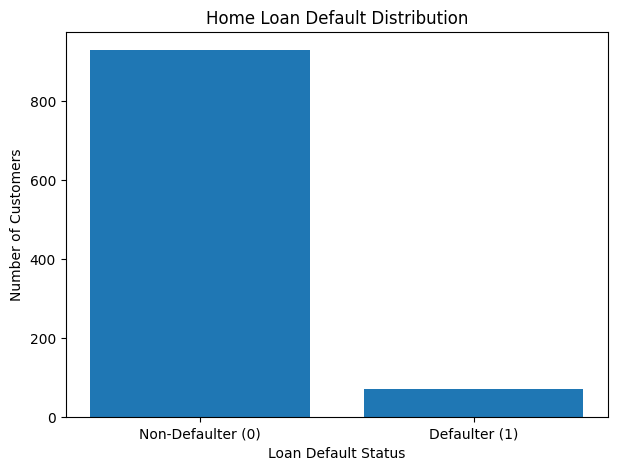

In [149]:
import matplotlib.pyplot as plt

target_counts = model_data['TARGET'].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ['Non-Defaulter (0)', 'Defaulter (1)'],
    target_counts.values
)

plt.title('Home Loan Default Distribution')
plt.xlabel('Loan Default Status')
plt.ylabel('Number of Customers')

plt.show()

In [150]:
numeric_columns = model_data.select_dtypes(
    include=['int64', 'float64']
).columns

print("Number of numerical columns:", len(numeric_columns))

numeric_summary = model_data[numeric_columns].describe().T

print("\nNumerical Feature Summary:")
display(numeric_summary.head(20))

Number of numerical columns: 176

Numerical Feature Summary:


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,1000.0,100575.487000,331.664661,100002.000000,100289.750000,100576.50000,100862.250000,1.011560e+05
TARGET,1000.0,0.070000,0.255275,0.000000,0.000000,0.00000,0.000000,1.000000e+00
CNT_CHILDREN,1000.0,0.406000,0.713914,0.000000,0.000000,0.00000,1.000000,3.000000e+00
AMT_INCOME_TOTAL,1000.0,167660.480655,90167.625149,31500.000000,112500.000000,144000.00000,202500.000000,7.650000e+05
AMT_CREDIT,1000.0,595306.363500,388475.193497,47970.000000,273584.250000,516514.50000,808650.000000,2.286212e+06
AMT_ANNUITY,1000.0,27120.672000,14278.923334,4504.500000,16603.875000,25371.00000,34103.250000,1.162665e+05
AMT_GOODS_PRICE,1000.0,536112.000000,359466.538983,45000.000000,238500.000000,450000.00000,679500.000000,2.250000e+06
REGION_POPULATION_RELATIVE,1000.0,0.021132,0.014033,0.001333,0.010006,0.01885,0.028663,7.250800e-02
DAYS_BIRTH,1000.0,-15872.748000,4235.854370,-25104.000000,-19229.000000,-15743.00000,-12326.500000,-7.705000e+03
DAYS_EMPLOYED,1000.0,55733.906000,134159.108526,-15632.000000,-2724.000000,-1267.00000,-304.000000,3.652430e+05


In [151]:
# Count unique values for every feature
unique_counts = model_data.nunique().sort_values()

print("Features with only 1 unique value:")
print(unique_counts[unique_counts == 1])

print("\nFeatures with 2 or fewer unique values:")
print(unique_counts[unique_counts <= 2])

Features with only 1 unique value:
FLAG_MOBIL                          1
FLAG_DOCUMENT_21                    1
MAX_OVERDUE_DAYS                    1
FLAG_DOCUMENT_10                    1
FLAG_DOCUMENT_12                    1
FLAG_DOCUMENT_2                     1
FLAG_DOCUMENT_7                     1
FLAG_DOCUMENT_4                     1
TOTAL_OVERDUE                       1
FLAG_DOCUMENT_17                    1
FLAG_DOCUMENT_20                    1
FLAG_DOCUMENT_19                    1
TOTAL_DPD_DEF_CREDIT_CARD           1
DPD_DEF_RECORD_COUNT_CREDIT_CARD    1
TOTAL_DPD_CREDIT_CARD               1
MAX_DPD_DEF_CREDIT_CARD             1
DPD_RECORD_COUNT_CREDIT_CARD        1
DPD_RECORD_COUNT                    1
MAX_DPD_DEF                         1
DPD_DEF_RECORD_COUNT                1
TOTAL_DPD                           1
MAX_DPD                             1
TOTAL_DPD_DEF                       1
TOTAL_UNUSED_OFFERS                 1
TOTAL_CREDIT_HISTORY_MONTHS         1
MAX_DELINQUENT_

In [152]:
# Identify features with only one unique value
constant_features = [
    col for col in model_data.columns
    if model_data[col].nunique() <= 1
]

print("Number of constant features:", len(constant_features))

print("\nConstant features:")
print(constant_features)

# Remove constant features
model_data = model_data.drop(
    columns=constant_features
)

print("\nNew dataset shape:", model_data.shape)

Number of constant features: 33

Constant features:
['FLAG_MOBIL', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'TOTAL_OVERDUE', 'MAX_OVERDUE_DAYS', 'PREVIOUS_CREDIT_COUNT_BUREAU', 'TOTAL_CREDIT_BUREAU', 'TOTAL_DEBT_BUREAU', 'TOTAL_OVERDUE_BUREAU', 'MAX_OVERDUE_DAYS_BUREAU', 'TOTAL_DELINQUENT_MONTHS', 'MAX_DELINQUENT_STATUS', 'TOTAL_CREDIT_HISTORY_MONTHS', 'TOTAL_UNUSED_OFFERS', 'MAX_DPD', 'TOTAL_DPD', 'DPD_RECORD_COUNT', 'MAX_DPD_DEF', 'TOTAL_DPD_DEF', 'DPD_DEF_RECORD_COUNT', 'MAX_DPD_CREDIT_CARD', 'TOTAL_DPD_CREDIT_CARD', 'DPD_RECORD_COUNT_CREDIT_CARD', 'MAX_DPD_DEF_CREDIT_CARD', 'TOTAL_DPD_DEF_CREDIT_CARD', 'DPD_DEF_RECORD_COUNT_CREDIT_CARD']

New dataset shape: (1000, 159)


In [153]:
print("DAYS_EMPLOYED summary:")
print(model_data['DAYS_EMPLOYED'].describe())

print("\nPositive DAYS_EMPLOYED values:")
print(
    (model_data['DAYS_EMPLOYED'] > 0).sum()
)

print("\nMaximum DAYS_EMPLOYED:")
print(model_data['DAYS_EMPLOYED'].max())

DAYS_EMPLOYED summary:
count      1000.000000
mean      55733.906000
std      134159.108526
min      -15632.000000
25%       -2724.000000
50%       -1267.000000
75%        -304.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Positive DAYS_EMPLOYED values:
158

Maximum DAYS_EMPLOYED:
365243


In [154]:
# Identify anomalous positive employment-day values
employment_anomaly_count = (
    model_data['DAYS_EMPLOYED'] > 0
).sum()

print("Anomalous positive values:",
      employment_anomaly_count)

# Replace anomalous values with NaN
model_data.loc[
    model_data['DAYS_EMPLOYED'] > 0,
    'DAYS_EMPLOYED'
] = float('nan')

# Calculate median from valid employment values
employment_median = model_data['DAYS_EMPLOYED'].median()

print("Median of valid DAYS_EMPLOYED:",
      employment_median)

# Impute anomalous values using median
model_data['DAYS_EMPLOYED'] = (
    model_data['DAYS_EMPLOYED']
    .fillna(employment_median)
)

print("\nDAYS_EMPLOYED after treatment:")
print(model_data['DAYS_EMPLOYED'].describe())

Anomalous positive values: 158
Median of valid DAYS_EMPLOYED: -1553.5

DAYS_EMPLOYED after treatment:
count     1000.00000
mean     -2219.94100
std       2192.49687
min     -15632.00000
25%      -2724.00000
50%      -1553.50000
75%       -890.00000
max        -17.00000
Name: DAYS_EMPLOYED, dtype: float64


In [155]:
# Convert negative day-based variables into interpretable years

model_data['AGE_YEARS'] = (
    -model_data['DAYS_BIRTH'] / 365.25
)

model_data['EMPLOYMENT_YEARS'] = (
    -model_data['DAYS_EMPLOYED'] / 365.25
)

print("Age statistics:")
print(model_data['AGE_YEARS'].describe())

print("\nEmployment years statistics:")
print(model_data['EMPLOYMENT_YEARS'].describe())

Age statistics:
count    1000.000000
mean       43.457216
std        11.597137
min        21.095140
25%        33.748118
50%        43.101985
75%        52.646133
max        68.731006
Name: AGE_YEARS, dtype: float64

Employment years statistics:
count    1000.000000
mean        6.077867
std         6.002729
min         0.046543
25%         2.436687
50%         4.253251
75%         7.457906
max        42.798084
Name: EMPLOYMENT_YEARS, dtype: float64


/tmp/ipykernel_3779/1188057883.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_data['AGE_YEARS'] = (
/tmp/ipykernel_3779/1188057883.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_data['EMPLOYMENT_YEARS'] = (


In [156]:
model_data = model_data.copy()

print("DataFrame shape:", model_data.shape)

DataFrame shape: (1000, 161)


In [157]:
invalid_employment = model_data[
    model_data['EMPLOYMENT_YEARS'] > model_data['AGE_YEARS']
]

print("Customers with employment years greater than age:",
      len(invalid_employment))

Customers with employment years greater than age: 0


In [158]:
print(
    model_data[['AGE_YEARS', 'EMPLOYMENT_YEARS']].describe()
)

         AGE_YEARS  EMPLOYMENT_YEARS
count  1000.000000       1000.000000
mean     43.457216          6.077867
std      11.597137          6.002729
min      21.095140          0.046543
25%      33.748118          2.436687
50%      43.101985          4.253251
75%      52.646133          7.457906
max      68.731006         42.798084


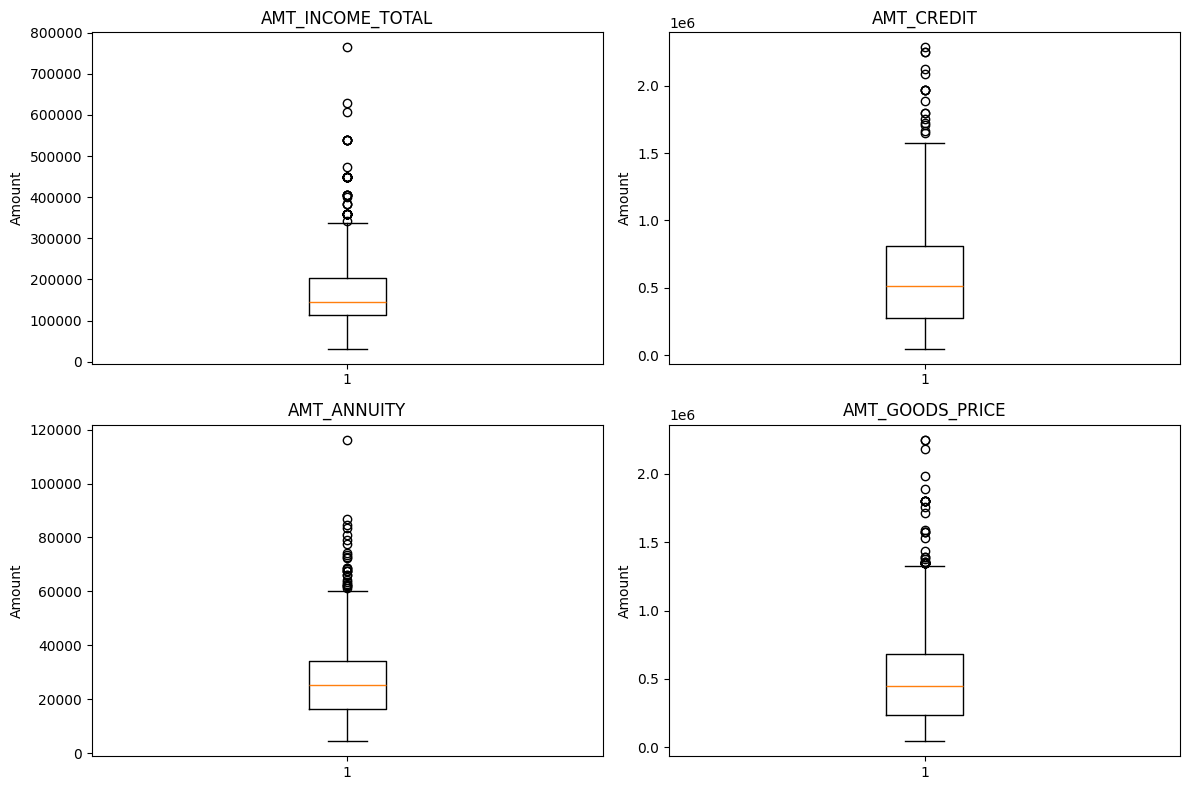

In [159]:
import matplotlib.pyplot as plt

financial_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE'
]

plt.figure(figsize=(12, 8))

for i, col in enumerate(financial_cols, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(model_data[col])
    plt.title(col)
    plt.ylabel('Amount')

plt.tight_layout()
plt.show()

In [160]:
# Financial ratio features

model_data['CREDIT_INCOME_RATIO'] = (
    model_data['AMT_CREDIT'] /
    model_data['AMT_INCOME_TOTAL'].replace(0, float('nan'))
)

model_data['ANNUITY_INCOME_RATIO'] = (
    model_data['AMT_ANNUITY'] /
    model_data['AMT_INCOME_TOTAL'].replace(0, float('nan'))
)

model_data['CREDIT_GOODS_RATIO'] = (
    model_data['AMT_CREDIT'] /
    model_data['AMT_GOODS_PRICE'].replace(0, float('nan'))
)

model_data['INCOME_PER_FAMILY_MEMBER'] = (
    model_data['AMT_INCOME_TOTAL'] /
    model_data['CNT_FAM_MEMBERS'].replace(0, float('nan'))
)

# Check the new features
ratio_cols = [
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_GOODS_RATIO',
    'INCOME_PER_FAMILY_MEMBER'
]

print(model_data[ratio_cols].describe())

       CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  CREDIT_GOODS_RATIO  \
count          1000.000000           1000.000000         1000.000000   
mean              3.924471              0.180785            1.121304   
std               2.652051              0.098988            0.124069   
min               0.285714              0.014300            0.300000   
25%               2.019667              0.116094            1.000000   
50%               3.177965              0.161417            1.118799   
75%               5.289971              0.227779            1.198000   
max              34.916667              1.373917            1.660000   

       INCOME_PER_FAMILY_MEMBER  
count               1000.000000  
mean               94052.273828  
std                69648.159056  
min                10800.000000  
25%                49500.000000  
50%                76500.000000  
75%               112500.000000  
max               765000.000000  


In [161]:
ratio_cols = [
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_GOODS_RATIO',
    'INCOME_PER_FAMILY_MEMBER'
]

for col in ratio_cols:
    Q1 = model_data[col].quantile(0.25)
    Q3 = model_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = model_data[
        (model_data[col] < lower_bound) |
        (model_data[col] > upper_bound)
    ]

    print(f"\n{col}")
    print(f"Q1: {Q1:.4f}")
    print(f"Q3: {Q3:.4f}")
    print(f"IQR: {IQR:.4f}")
    print(f"Lower Bound: {lower_bound:.4f}")
    print(f"Upper Bound: {upper_bound:.4f}")
    print(f"Outlier Count: {len(outliers)}")


CREDIT_INCOME_RATIO
Q1: 2.0197
Q3: 5.2900
IQR: 3.2703
Lower Bound: -2.8858
Upper Bound: 10.1954
Outlier Count: 21

ANNUITY_INCOME_RATIO
Q1: 0.1161
Q3: 0.2278
IQR: 0.1117
Lower Bound: -0.0514
Upper Bound: 0.3953
Outlier Count: 30

CREDIT_GOODS_RATIO
Q1: 1.0000
Q3: 1.1980
IQR: 0.1980
Lower Bound: 0.7030
Upper Bound: 1.4950
Outlier Count: 8

INCOME_PER_FAMILY_MEMBER
Q1: 49500.0000
Q3: 112500.0000
IQR: 63000.0000
Lower Bound: -45000.0000
Upper Bound: 207000.0000
Outlier Count: 64


In [162]:
target_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'AGE_YEARS',
    'EMPLOYMENT_YEARS',
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_GOODS_RATIO',
    'INCOME_PER_FAMILY_MEMBER'
]

target_summary = (
    model_data
    .groupby('TARGET')[target_features]
    .mean()
    .T
)

target_summary.columns = ['Non-Defaulter (0)', 'Defaulter (1)']

print(target_summary)

                          Non-Defaulter (0)  Defaulter (1)
AMT_INCOME_TOTAL              167838.951242  165289.371429
AMT_CREDIT                    594414.091935  607160.828571
AMT_ANNUITY                    27024.653226   28396.350000
AMT_GOODS_PRICE               536288.709677  533764.285714
AGE_YEARS                         43.719762      39.969101
EMPLOYMENT_YEARS                   6.254267       3.734272
CREDIT_INCOME_RATIO                3.892942       4.343352
ANNUITY_INCOME_RATIO               0.179284       0.200735
CREDIT_GOODS_RATIO                 1.117879       1.166810
INCOME_PER_FAMILY_MEMBER       93837.519169   96905.442857


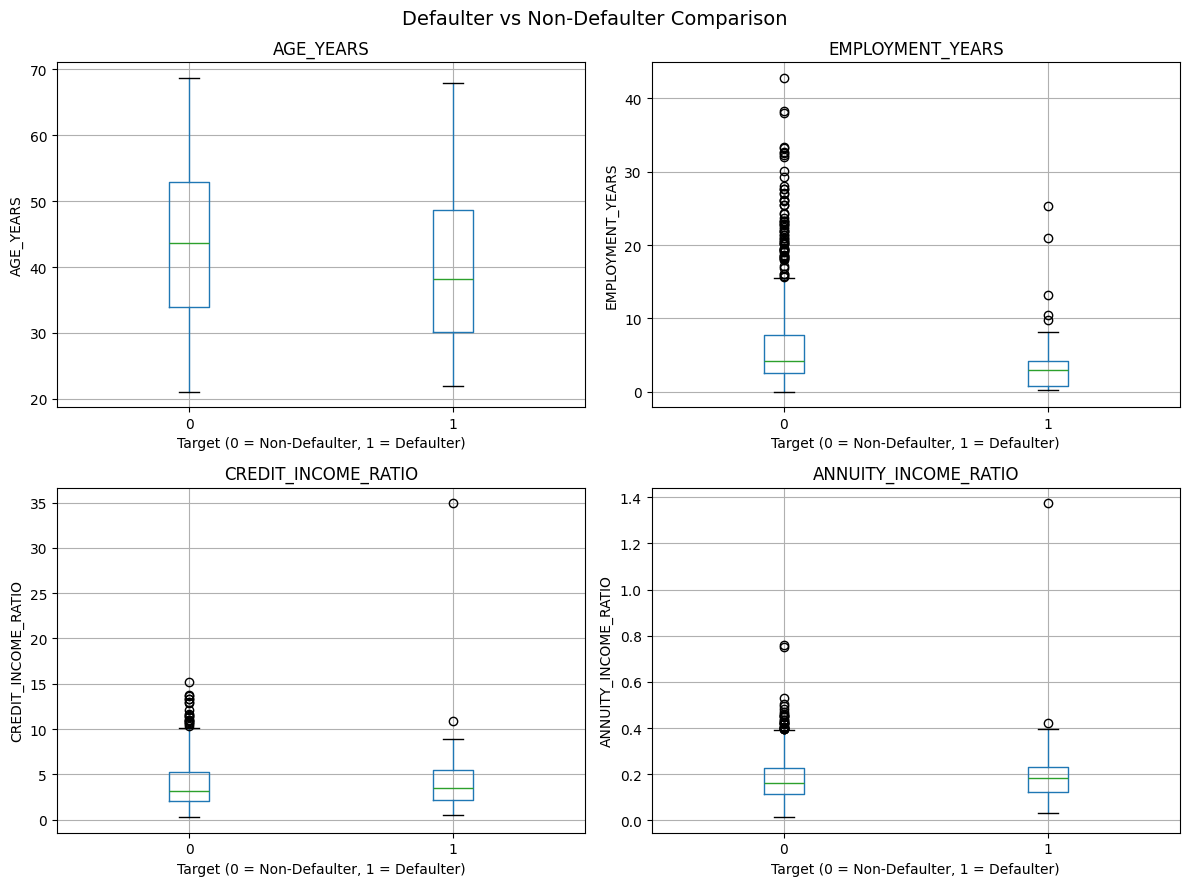

In [163]:
import matplotlib.pyplot as plt

comparison_features = [
    'AGE_YEARS',
    'EMPLOYMENT_YEARS',
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.flatten(), comparison_features):
    model_data.boxplot(
        column=feature,
        by='TARGET',
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel('Target (0 = Non-Defaulter, 1 = Defaulter)')
    ax.set_ylabel(feature)

plt.suptitle('Defaulter vs Non-Defaulter Comparison', fontsize=14)
plt.tight_layout()
plt.show()


EDA Finding: Defaulters in the sampled dataset tend to be younger and have shorter employment durations than non-defaulters. They also show somewhat higher credit-to-income and annuity-to-income ratios, indicating a potentially higher financial burden relative to income. However, substantial overlap exists between the two groups, so these variables should be considered together with other customer and financial characteristics rather than used independently for classification.

In [164]:
categorical_features = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'NAME_EDUCATION_TYPE',
    'NAME_INCOME_TYPE'
]

for col in categorical_features:
    print(f"\n{'='*60}")
    print(f"{col}")
    print(f"{'='*60}")

    summary = (
        model_data.groupby(col)['TARGET']
        .agg(['count', 'mean'])
        .sort_values('mean', ascending=False)
    )

    summary['default_rate_percent'] = summary['mean'] * 100

    print(summary)


NAME_CONTRACT_TYPE
                    count      mean  default_rate_percent
NAME_CONTRACT_TYPE                                       
Cash loans            903  0.073090              7.308970
Revolving loans        97  0.041237              4.123711

CODE_GENDER
             count      mean  default_rate_percent
CODE_GENDER                                       
M              356  0.095506              9.550562
F              644  0.055901              5.590062

NAME_EDUCATION_TYPE
                               count      mean  default_rate_percent
NAME_EDUCATION_TYPE                                                 
Secondary / secondary special    703  0.083926              8.392603
Incomplete higher                 29  0.068966              6.896552
Higher education                 259  0.034749              3.474903
Lower secondary                    9  0.000000              0.000000

NAME_INCOME_TYPE
                      count      mean  default_rate_percent
NAME_INCOME_TYPE  

Categorical EDA Finding: Default rates vary across contract type, gender, education level, and income type in the sampled dataset. Cash loans, male customers, secondary education, and commercial associate income type show relatively higher observed default rates among the larger groups. However, these are descriptive associations rather than causal relationships. Categories with small sample sizes should be interpreted cautiously.

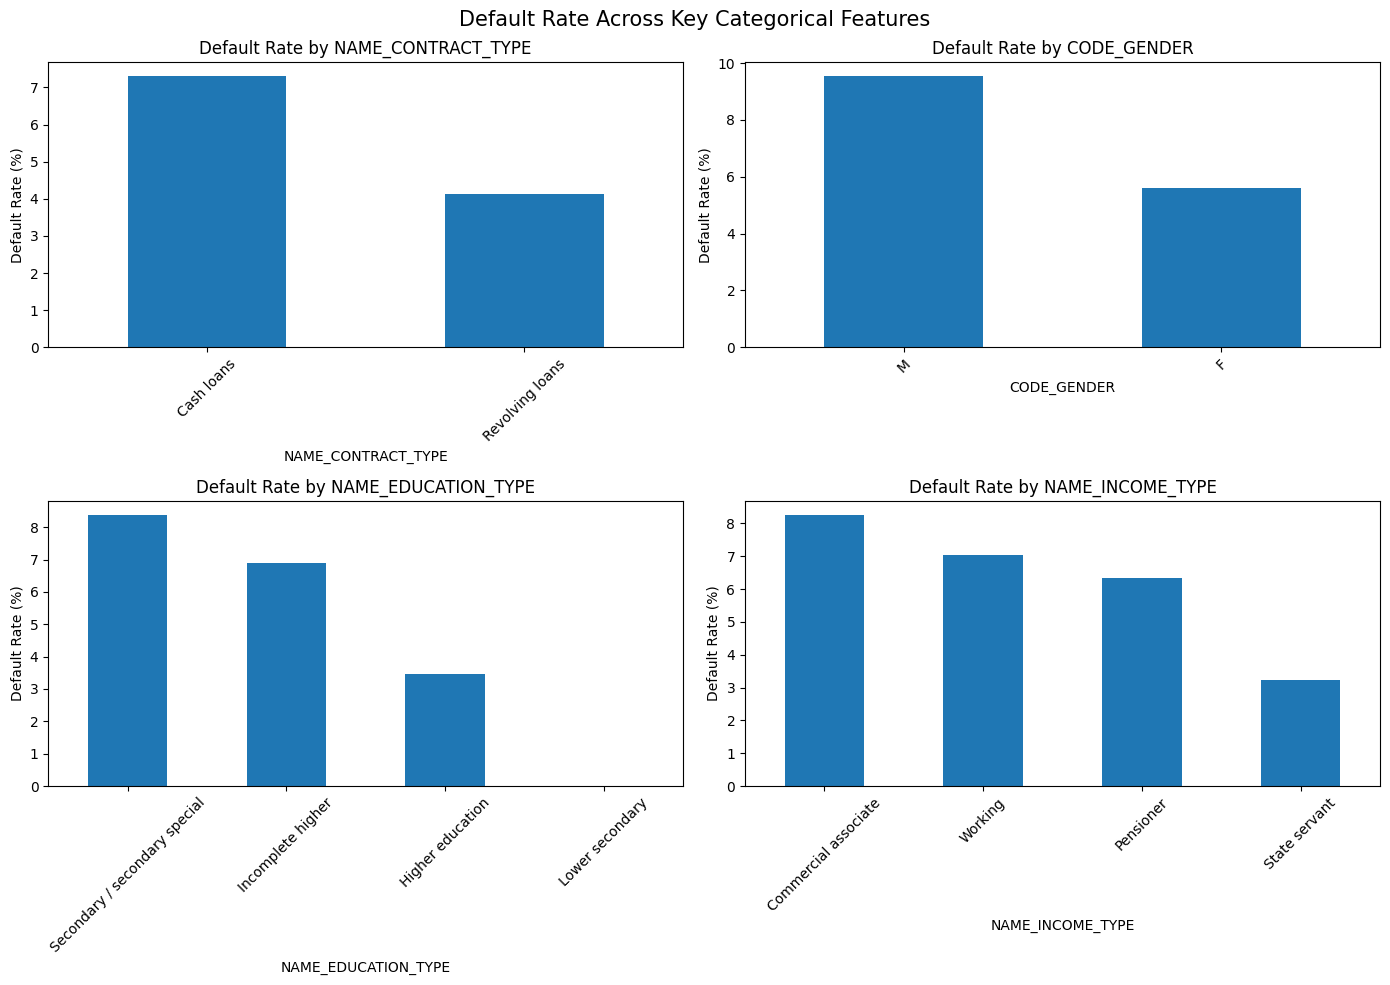

In [165]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), categorical_features):

    default_rates = (
        model_data.groupby(col)['TARGET']
        .mean()
        .sort_values(ascending=False) * 100
    )

    default_rates.plot(
        kind='bar',
        ax=ax
    )

    ax.set_title(f'Default Rate by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Default Rate (%)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    'Default Rate Across Key Categorical Features',
    fontsize=15
)

plt.tight_layout()
plt.show()

In [166]:
# Select numerical columns
numeric_data = model_data.select_dtypes(include=['number'])

# Calculate correlation with TARGET
target_correlation = (
    numeric_data.corr()['TARGET']
    .drop('TARGET')
    .sort_values(key=abs, ascending=False)
)

print("Top 20 numerical features correlated with TARGET:")
print(target_correlation.head(20))

Top 20 numerical features correlated with TARGET:
EXT_SOURCE_3                   -0.204523
EXT_SOURCE_2                   -0.195208
DAYS_EMPLOYED                   0.107166
EMPLOYMENT_YEARS               -0.107166
CREDIT_GOODS_RATIO              0.100677
YEARS_BEGINEXPLUATATION_MEDI   -0.096293
FLAG_DOCUMENT_18                0.091685
AGE_YEARS                      -0.082559
DAYS_BIRTH                      0.082559
YEARS_BEGINEXPLUATATION_AVG    -0.078040
DAYS_LAST_PHONE_CHANGE          0.074336
YEARS_BEGINEXPLUATATION_MODE   -0.070503
EXT_SOURCE_1                   -0.069425
ANNUITY_INCOME_RATIO            0.055321
DAYS_ID_PUBLISH                 0.055298
REG_REGION_NOT_LIVE_REGION      0.051294
AMT_REQ_CREDIT_BUREAU_MON       0.051238
COMMONAREA_MODE                 0.050185
REG_CITY_NOT_WORK_CITY          0.049782
FLAG_WORK_PHONE                 0.049480
Name: TARGET, dtype: float64


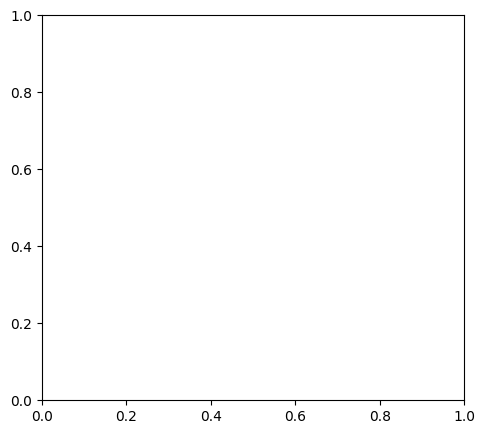

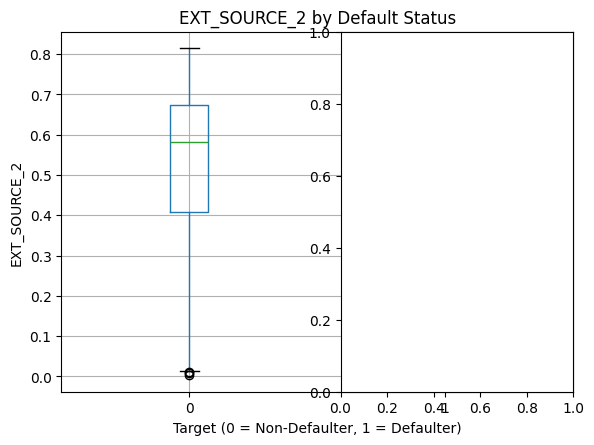

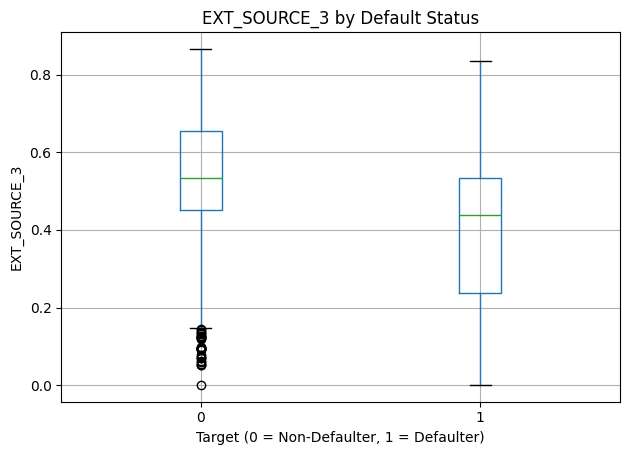

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
model_data.boxplot(
    column='EXT_SOURCE_2',
    by='TARGET'
)
plt.title('EXT_SOURCE_2 by Default Status')
plt.suptitle('')
plt.xlabel('Target (0 = Non-Defaulter, 1 = Defaulter)')
plt.ylabel('EXT_SOURCE_2')

plt.subplot(1, 2, 2)
model_data.boxplot(
    column='EXT_SOURCE_3',
    by='TARGET'
)
plt.title('EXT_SOURCE_3 by Default Status')
plt.suptitle('')
plt.xlabel('Target (0 = Non-Defaulter, 1 = Defaulter)')
plt.ylabel('EXT_SOURCE_3')

plt.tight_layout()
plt.show()

EDA Finding: EXT_SOURCE_2 and EXT_SOURCE_3 showed the strongest numerical associations with the target variable, with negative correlations of approximately -0.195 and -0.205 respectively. The boxplots also show lower distributions for these variables among defaulters. These features may therefore provide useful predictive information when combined with other customer and financial characteristics.

In [168]:
# Remove redundant original features
redundant_features = [
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

model_data = model_data.drop(
    columns=redundant_features,
    errors='ignore'
)

print("New dataset shape:", model_data.shape)

New dataset shape: (1000, 162)


In [169]:
print("Missing values:", model_data.isnull().sum().sum())
print("Duplicate customer IDs:", model_data['SK_ID_CURR'].duplicated().sum())
print("Target distribution:")
print(model_data['TARGET'].value_counts())

Missing values: 0
Duplicate customer IDs: 0
Target distribution:
TARGET
0    930
1     70
Name: count, dtype: int64


In [170]:
# Separate customer ID, features and target

# Keep customer IDs separately for later risk analysis
customer_ids = model_data['SK_ID_CURR'].copy()

# Remove ID and target from model features
X = model_data.drop(
    columns=['TARGET', 'SK_ID_CURR']
)

y = model_data['TARGET']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (1000, 160)
y shape: (1000,)

Target distribution:
TARGET
0    930
1     70
Name: count, dtype: int64


In [171]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining default rate:",
      round(y_train.mean() * 100, 2), "%")

print("Testing default rate:",
      round(y_test.mean() * 100, 2), "%")

Training set: (800, 160)
Testing set: (200, 160)

Training target distribution:
TARGET
0    744
1     56
Name: count, dtype: int64

Testing target distribution:
TARGET
0    186
1     14
Name: count, dtype: int64

Training default rate: 7.0 %
Testing default rate: 7.0 %


In [207]:
# Keep customer IDs corresponding to the test set

test_customer_ids = customer_ids.loc[X_test.index]

print("Test customer IDs:", test_customer_ids.shape)
print(test_customer_ids.head())

Test customer IDs: (200,)
203    100236
488    100563
424    100490
105    100124
75     100087
Name: SK_ID_CURR, dtype: int64


In [172]:
# Identify numerical and categorical features

numeric_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 144
Number of categorical features: 16

Categorical features:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [173]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder='drop'
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [174]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (800, 275)
Processed testing shape: (200, 275)


In [175]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [176]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

y_pred_lr = logistic_model.predict(X_test_processed)
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression Results")
print("-" * 40)

print("Accuracy :", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_lr, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_lr, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lr), 4))
print("PR-AUC   :", round(average_precision_score(y_test, y_prob_lr), 4))

Logistic Regression Results
----------------------------------------
Accuracy : 0.79
Precision: 0.15
Recall   : 0.4286
F1 Score : 0.2222
ROC-AUC  : 0.6813
PR-AUC   : 0.1532


In [177]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=5,
    random_state=42
)

decision_tree_model.fit(X_train_processed, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [178]:
y_pred_dt = decision_tree_model.predict(X_test_processed)
y_prob_dt = decision_tree_model.predict_proba(X_test_processed)[:, 1]

print("Decision Tree Results")
print("-" * 40)
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dt, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_dt, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_dt), 4))
print("PR-AUC   :", round(average_precision_score(y_test, y_prob_dt), 4))

Decision Tree Results
----------------------------------------
Accuracy : 0.705
Precision: 0.1186
Recall   : 0.5
F1 Score : 0.1918
ROC-AUC  : 0.605
PR-AUC   : 0.1002


In [179]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [180]:
y_pred_rf = random_forest_model.predict(X_test_processed)
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest Results")
print("-" * 40)
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_rf, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_rf, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf), 4))
print("PR-AUC   :", round(average_precision_score(y_test, y_prob_rf), 4))

Random Forest Results
----------------------------------------
Accuracy : 0.93
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.6494
PR-AUC   : 0.1191


In [181]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train_processed, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [182]:
y_pred_gb = gradient_boosting_model.predict(X_test_processed)
y_prob_gb = gradient_boosting_model.predict_proba(X_test_processed)[:, 1]

print("Gradient Boosting Results")
print("-" * 40)
print("Accuracy :", round(accuracy_score(y_test, y_pred_gb), 4))
print("Precision:", round(precision_score(y_test, y_pred_gb, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_gb, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_gb, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_gb), 4))
print("PR-AUC   :", round(average_precision_score(y_test, y_prob_gb), 4))

Gradient Boosting Results
----------------------------------------
Accuracy : 0.915
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.6576
PR-AUC   : 0.1453


In [183]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Stratified Cross-Validation created.")

5-Fold Stratified Cross-Validation created.


In [184]:
lr_cv_scores = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("Logistic Regression CV ROC-AUC")
print("Scores:", lr_cv_scores)
print("Mean :", round(lr_cv_scores.mean(), 4))
print("Std  :", round(lr_cv_scores.std(), 4))

Logistic Regression CV ROC-AUC
Scores: [0.585723   0.61439902 0.63880415 0.68151312 0.60078829]
Mean : 0.6242
Std  : 0.0335


In [185]:
dt_cv_scores = cross_val_score(
    decision_tree_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("Decision Tree CV ROC-AUC")
print("Scores:", dt_cv_scores)
print("Mean :", round(dt_cv_scores.mean(), 4))
print("Std  :", round(dt_cv_scores.std(), 4))

Decision Tree CV ROC-AUC
Scores: [0.51311775 0.71415497 0.6442953  0.60646736 0.74408784]
Mean : 0.6444
Std  : 0.0818


In [186]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("Random Forest CV ROC-AUC")
print("Scores:", rf_cv_scores)
print("Mean :", round(rf_cv_scores.mean(), 4))
print("Std  :", round(rf_cv_scores.std(), 4))

Random Forest CV ROC-AUC
Scores: [0.6442953  0.67785235 0.63087248 0.65344722 0.69538288]
Mean : 0.6604
Std  : 0.0233


In [187]:
gb_cv_scores = cross_val_score(
    gradient_boosting_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print("Gradient Boosting CV ROC-AUC")
print("Scores:", gb_cv_scores)
print("Mean :", round(gb_cv_scores.mean(), 4))
print("Std  :", round(gb_cv_scores.std(), 4))

Gradient Boosting CV ROC-AUC
Scores: [0.80170836 0.7614399  0.71507016 0.6519219  0.75788288]
Mean : 0.7376
Std  : 0.0509


In [188]:
import numpy as np

print("Gradient Boosting probability statistics")
print("-" * 45)

print("Minimum :", round(y_prob_gb.min(), 4))
print("Maximum :", round(y_prob_gb.max(), 4))
print("Mean    :", round(y_prob_gb.mean(), 4))
print("Median  :", round(np.median(y_prob_gb), 4))

Gradient Boosting probability statistics
---------------------------------------------
Minimum : 0.0098
Maximum : 0.6506
Mean    : 0.0665
Median  : 0.0298


In [189]:
print("Probability percentiles")
print("-" * 45)

for p in [50, 75, 90, 95, 99]:
    print(f"{p}th percentile:", round(np.percentile(y_prob_gb, p), 4))

Probability percentiles
---------------------------------------------
50th percentile: 0.0298
75th percentile: 0.0612
90th percentile: 0.1333
95th percentile: 0.231
99th percentile: 0.5625


In [190]:
print("Random Forest probability statistics")
print("-" * 45)

print("Minimum :", round(y_prob_rf.min(), 4))
print("Maximum :", round(y_prob_rf.max(), 4))
print("Mean    :", round(y_prob_rf.mean(), 4))
print("Median  :", round(np.median(y_prob_rf), 4))

Random Forest probability statistics
---------------------------------------------
Minimum : 0.0475
Maximum : 0.4518
Mean    : 0.1894
Median  : 0.1739


In [191]:
print("Probability percentiles")
print("-" * 45)

for p in [50, 75, 90, 95, 99]:
    print(f"{p}th percentile:", round(np.percentile(y_prob_rf, p), 4))

Probability percentiles
---------------------------------------------
50th percentile: 0.1739
75th percentile: 0.231
90th percentile: 0.3088
95th percentile: 0.3773
99th percentile: 0.4483


In [192]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.40, 0.30, 0.20, 0.10, 0.05]

print("Gradient Boosting Threshold Analysis")
print("-" * 60)

for threshold in thresholds:

    y_pred_threshold = (y_prob_gb >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Gradient Boosting Threshold Analysis
------------------------------------------------------------
Threshold: 0.50 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.40 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.30 | Precision: 0.1111 | Recall: 0.0714 | F1: 0.0870
Threshold: 0.20 | Precision: 0.1429 | Recall: 0.1429 | F1: 0.1429
Threshold: 0.10 | Precision: 0.2121 | Recall: 0.5000 | F1: 0.2979
Threshold: 0.05 | Precision: 0.1194 | Recall: 0.5714 | F1: 0.1975


In [193]:
print("Random Forest Threshold Analysis")
print("-" * 60)

for threshold in thresholds:

    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Random Forest Threshold Analysis
------------------------------------------------------------
Threshold: 0.50 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.40 | Precision: 0.1250 | Recall: 0.0714 | F1: 0.0909
Threshold: 0.30 | Precision: 0.0800 | Recall: 0.1429 | F1: 0.1026
Threshold: 0.20 | Precision: 0.1169 | Recall: 0.6429 | F1: 0.1978
Threshold: 0.10 | Precision: 0.0743 | Recall: 0.9286 | F1: 0.1376
Threshold: 0.05 | Precision: 0.0704 | Recall: 1.0000 | F1: 0.1315


In [194]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Create Gradient Boosting model
gb_cv_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Get Out-of-Fold probabilities
oof_prob_gb = cross_val_predict(
    gb_cv_model,
    X_train_processed,
    y_train,
    cv=cv,
    method='predict_proba'
)[:, 1]

print("Out-of-Fold predictions created.")
print("Minimum probability:", oof_prob_gb.min())
print("Maximum probability:", oof_prob_gb.max())

Out-of-Fold predictions created.
Minimum probability: 0.008512065906075915
Maximum probability: 0.9222059717943111


In [195]:
# Threshold analysis using Out-of-Fold predictions

thresholds = np.arange(0.05, 0.51, 0.01)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (oof_prob_gb >= threshold).astype(int)

    precision = precision_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        'Threshold': round(threshold, 2),
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

# Sort by F1 score
threshold_results_df.sort_values(
    by='F1',
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
3,0.08,0.167883,0.410714,0.238342
2,0.07,0.155689,0.464286,0.233184
0,0.05,0.142857,0.607143,0.231293
4,0.09,0.169492,0.357143,0.229885
1,0.06,0.139175,0.482143,0.216000
5,0.10,0.165049,0.303571,0.213836
6,0.11,0.149425,0.232143,0.181818
8,0.13,0.155844,0.214286,0.180451
9,0.14,0.161765,0.196429,0.177419
7,0.12,0.150000,0.214286,0.176471


In [196]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Final Gradient Boosting model
final_gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train on the complete training set
final_gb_model.fit(
    X_train_processed,
    y_train
)

# Get probability predictions on untouched test set
test_probabilities = final_gb_model.predict_proba(
    X_test_processed
)[:, 1]

# Selected threshold from cross-validation
final_threshold = 0.08

# Convert probabilities into classes
y_test_pred_final = (
    test_probabilities >= final_threshold
).astype(int)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_test_pred_final)

precision = precision_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_test_pred_final,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

print("FINAL GRADIENT BOOSTING MODEL")
print("=" * 40)

print(f"Threshold : {final_threshold}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred_final,
    target_names=["Non-Defaulter", "Defaulter"],
    zero_division=0
))

FINAL GRADIENT BOOSTING MODEL
Threshold : 0.08
Accuracy  : 0.7950
Precision : 0.1707
Recall    : 0.5000
F1 Score  : 0.2545
ROC-AUC   : 0.6576
PR-AUC    : 0.1453

Confusion Matrix:
[[152  34]
 [  7   7]]

Classification Report:
               precision    recall  f1-score   support

Non-Defaulter       0.96      0.82      0.88       186
    Defaulter       0.17      0.50      0.25        14

     accuracy                           0.80       200
    macro avg       0.56      0.66      0.57       200
 weighted avg       0.90      0.80      0.84       200



In [197]:
# Get feature names after preprocessing

feature_names = preprocessor.get_feature_names_out()

# Get feature importance from the final Gradient Boosting model
feature_importance = final_gb_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

# Display top 20 features
feature_importance_df.head(20)

,Feature,Importance
0,num__EXT_SOURCE_2,0.150468
1,num__DAYS_ID_PUBLISH,0.106677
2,num__EXT_SOURCE_3,0.105737
3,num__EMPLOYMENT_YEARS,0.080683
4,num__EXT_SOURCE_1,0.043512
5,num__CREDIT_GOODS_RATIO,0.042563
6,num__CREDIT_INCOME_RATIO,0.038532
7,num__AGE_YEARS,0.035020
8,num__REGION_POPULATION_RELATIVE,0.028065
9,cat__ORGANIZATION_TYPE_Security,0.024782


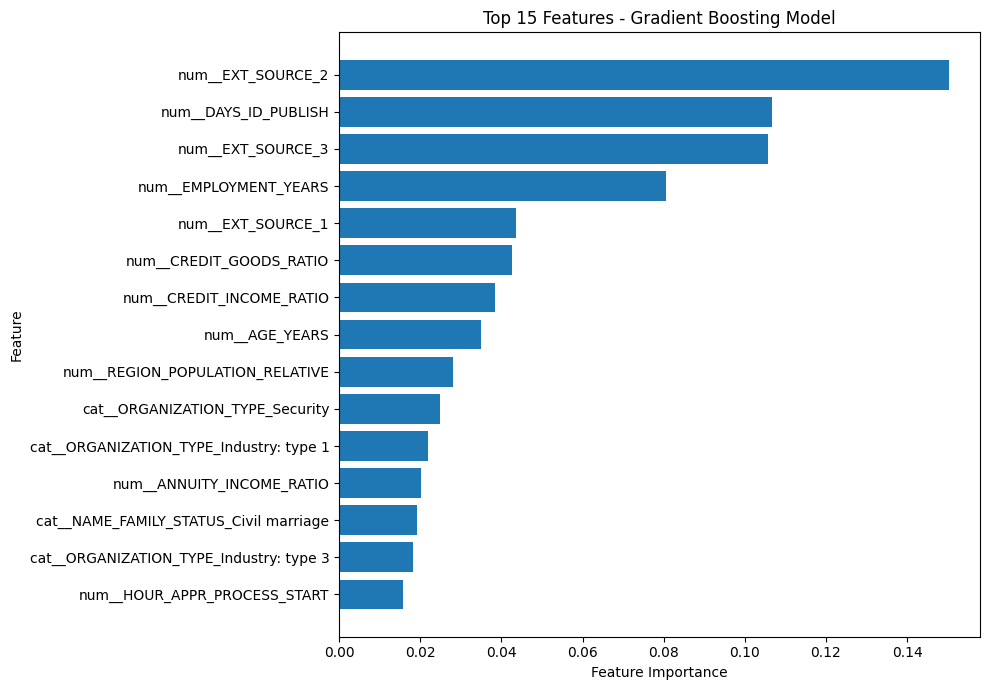

In [198]:
import matplotlib.pyplot as plt

# Select top 15 features
top_features = feature_importance_df.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features - Gradient Boosting Model')

plt.tight_layout()
plt.show()

In [199]:
# Analyze important numerical features against default

important_numeric_features = [
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'EMPLOYMENT_YEARS',
    'CREDIT_GOODS_RATIO',
    'CREDIT_INCOME_RATIO',
    'AGE_YEARS',
    'ANNUITY_INCOME_RATIO'
]

risk_analysis = []

for feature in important_numeric_features:

    non_default_mean = model_data.loc[
        model_data['TARGET'] == 0, feature
    ].mean()

    default_mean = model_data.loc[
        model_data['TARGET'] == 1, feature
    ].mean()

    risk_analysis.append({
        'Feature': feature,
        'Non_Default_Mean': non_default_mean,
        'Default_Mean': default_mean
    })

risk_analysis_df = pd.DataFrame(risk_analysis)

risk_analysis_df

,Feature,Non_Default_Mean,Default_Mean
0,EXT_SOURCE_1,0.508181,0.470414
1,EXT_SOURCE_2,0.526457,0.376810
2,EXT_SOURCE_3,0.527435,0.384903
3,EMPLOYMENT_YEARS,6.254267,3.734272
4,CREDIT_GOODS_RATIO,1.117879,1.166810
5,CREDIT_INCOME_RATIO,3.892942,4.343352
6,AGE_YEARS,43.719762,39.969101
7,ANNUITY_INCOME_RATIO,0.179284,0.200735


In [200]:
# Gradient Boosting Cross-Validation Stability

gb_cv_scores = np.array([
    0.79011592,
    0.76815131,
    0.70652837,
    0.65131178,
    0.75788288
])

gb_cv_summary = pd.DataFrame({
    'Metric': [
        'Mean ROC-AUC',
        'Standard Deviation',
        'Minimum ROC-AUC',
        'Maximum ROC-AUC',
        'Range'
    ],

    'Value': [
        gb_cv_scores.mean(),
        gb_cv_scores.std(),
        gb_cv_scores.min(),
        gb_cv_scores.max(),
        gb_cv_scores.max() - gb_cv_scores.min()
    ]
})

gb_cv_summary

,Metric,Value
0,Mean ROC-AUC,0.734798
1,Standard Deviation,0.049949
2,Minimum ROC-AUC,0.651312
3,Maximum ROC-AUC,0.790116
4,Range,0.138804


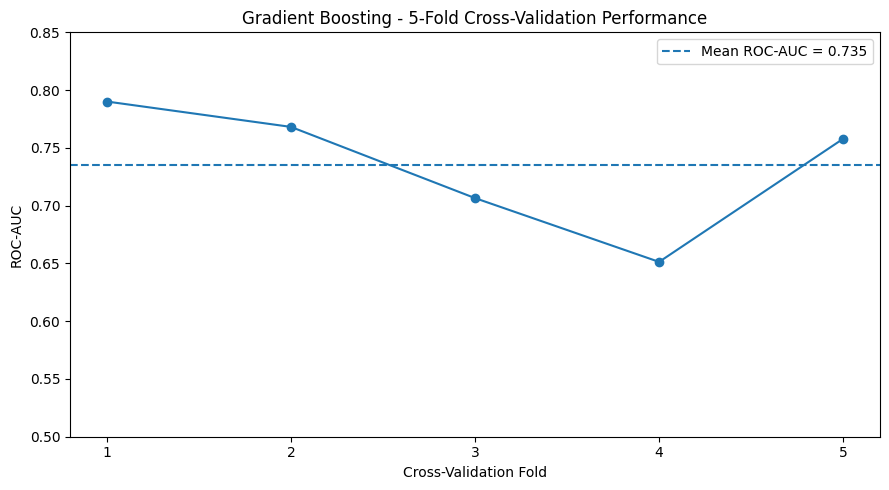

In [201]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, 6),
    gb_cv_scores,
    marker='o'
)

plt.axhline(
    gb_cv_scores.mean(),
    linestyle='--',
    label=f'Mean ROC-AUC = {gb_cv_scores.mean():.3f}'
)

plt.xlabel('Cross-Validation Fold')
plt.ylabel('ROC-AUC')
plt.title('Gradient Boosting - 5-Fold Cross-Validation Performance')

plt.xticks(range(1, 6))
plt.ylim(0.5, 0.85)

plt.legend()

plt.tight_layout()
plt.show()

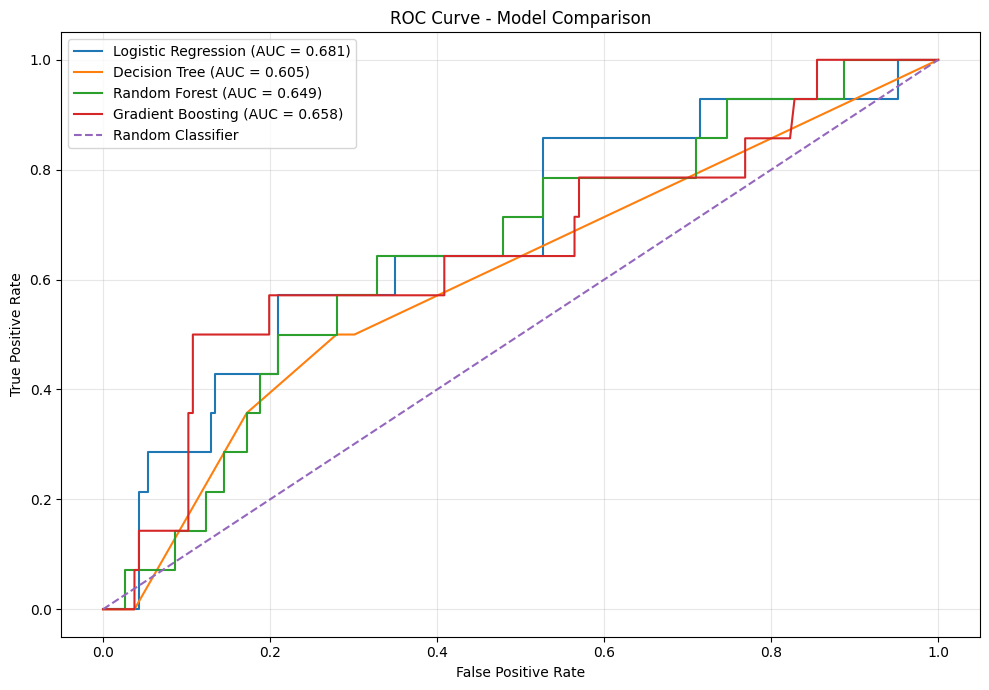

In [202]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Store models and their processed predictions
models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model,
    'Gradient Boosting': gradient_boosting_model
}

# Create figure for ROC curves
plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Probability of class 1 (default)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # ROC-AUC
    roc_auc_value = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {roc_auc_value:.3f})'
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

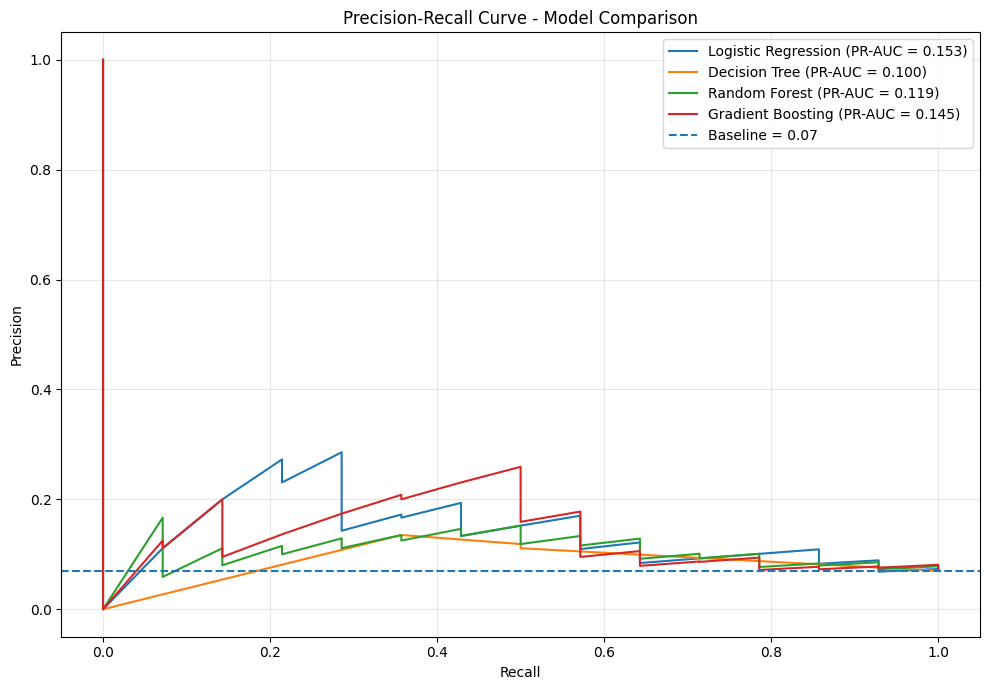

In [203]:
plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Probability of default
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    # PR-AUC
    pr_auc_value = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f'{name} (PR-AUC = {pr_auc_value:.3f})'
    )

# Baseline = proportion of positive class
positive_rate = y_test.mean()

plt.axhline(
    positive_rate,
    linestyle='--',
    label=f'Baseline = {positive_rate:.2f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Model Comparison')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [204]:
# Install SHAP if required
!pip install -q shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [205]:
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [206]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 features:")
print(feature_names[:20])

Number of processed features: 275

First 20 features:
['num__CNT_CHILDREN' 'num__AMT_INCOME_TOTAL' 'num__AMT_CREDIT'
 'num__AMT_ANNUITY' 'num__AMT_GOODS_PRICE'
 'num__REGION_POPULATION_RELATIVE' 'num__DAYS_REGISTRATION'
 'num__DAYS_ID_PUBLISH' 'num__OWN_CAR_AGE' 'num__FLAG_EMP_PHONE'
 'num__FLAG_WORK_PHONE' 'num__FLAG_CONT_MOBILE' 'num__FLAG_PHONE'
 'num__FLAG_EMAIL' 'num__CNT_FAM_MEMBERS' 'num__REGION_RATING_CLIENT'
 'num__REGION_RATING_CLIENT_W_CITY' 'num__HOUR_APPR_PROCESS_START'
 'num__REG_REGION_NOT_LIVE_REGION' 'num__REG_REGION_NOT_WORK_REGION']


In [ ]:
# Create SHAP Tree Explainer

explainer = shap.TreeExplainer(gradient_boosting_model)

shap_values = explainer.shap_values(X_test_processed)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (200, 275)


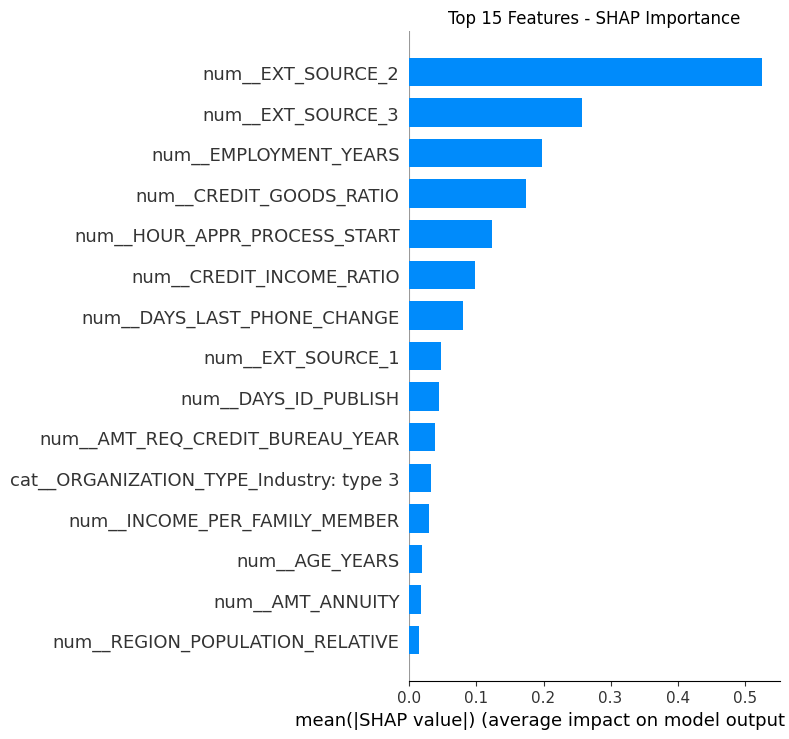

In [ ]:
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title("Top 15 Features - SHAP Importance")

plt.tight_layout()
plt.show()

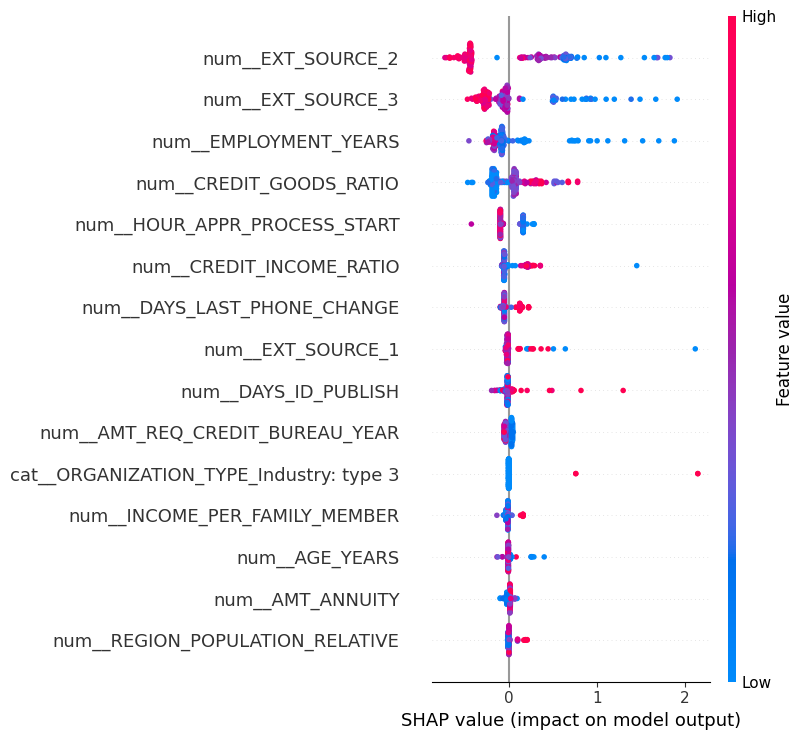

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    max_display=15
)

In [209]:
# Get predicted default probabilities from the final Gradient Boosting model

final_gb_probabilities = gradient_boosting_model.predict_proba(
    X_test_processed
)[:, 1]

print("Minimum probability:", final_gb_probabilities.min())
print("Maximum probability:", final_gb_probabilities.max())
print("Average probability:", final_gb_probabilities.mean())
print("Median probability:", np.median(final_gb_probabilities))

Minimum probability: 0.009847173016207664
Maximum probability: 0.6506111746204897
Average probability: 0.06647032057596788
Median probability: 0.029833244269669195


In [210]:
# Create risk analysis dataframe

risk_df = pd.DataFrame({
    'SK_ID_CURR': test_customer_ids.values,
    'Actual_Default': y_test.values,
    'Default_Probability': final_gb_probabilities
})

# Use our selected threshold
selected_threshold = 0.08

risk_df['Predicted_Default'] = (
    risk_df['Default_Probability'] >= selected_threshold
).astype(int)

risk_df.head(10)

,SK_ID_CURR,Actual_Default,Default_Probability,Predicted_Default
0,100236,0,0.042002,0
1,100563,0,0.100957,1
2,100490,1,0.126421,1
3,100124,0,0.019866,0
4,100087,0,0.032463,0
5,100688,0,0.053482,0
6,100582,0,0.020985,0
7,100802,0,0.084772,1
8,100335,0,0.020789,0
9,100199,0,0.367671,1


In [ ]:
def assign_risk_category(probability):

    if probability < 0.10:
        return 'Low Risk'

    elif probability < 0.30:
        return 'Medium Risk'

    elif probability < 0.50:
        return 'High Risk'

    else:
        return 'Very High Risk'


risk_df['Risk_Category'] = (
    risk_df['Default_Probability']
    .apply(assign_risk_category)
)

risk_df.head(10)

,SK_ID_CURR,Actual_Default,Default_Probability,Predicted_Default,Risk_Category
0,203,0,0.042002,0,Low Risk
1,488,0,0.100957,1,Medium Risk
2,424,1,0.126421,1,Medium Risk
3,105,0,0.019866,0,Low Risk
4,75,0,0.032463,0,Low Risk
5,601,0,0.053482,0,Low Risk
6,505,0,0.020985,0,Low Risk
7,693,0,0.084772,1,Low Risk
8,290,0,0.020789,0,Low Risk
9,170,0,0.367671,1,High Risk


In [ ]:
risk_distribution = (
    risk_df['Risk_Category']
    .value_counts()
    .reindex([
        'Low Risk',
        'Medium Risk',
        'High Risk',
        'Very High Risk'
    ])
    .fillna(0)
)

risk_distribution

,count
Risk_Category,
Low Risk,167
Medium Risk,24
High Risk,6
Very High Risk,3


In [ ]:
risk_distribution_percentage = (
    risk_distribution / len(risk_df) * 100
).round(2)

risk_summary = pd.DataFrame({
    'Customer_Count': risk_distribution.astype(int),
    'Percentage': risk_distribution_percentage
})

risk_summary

,Customer_Count,Percentage
Risk_Category,,
Low Risk,167,83.5
Medium Risk,24,12.0
High Risk,6,3.0
Very High Risk,3,1.5


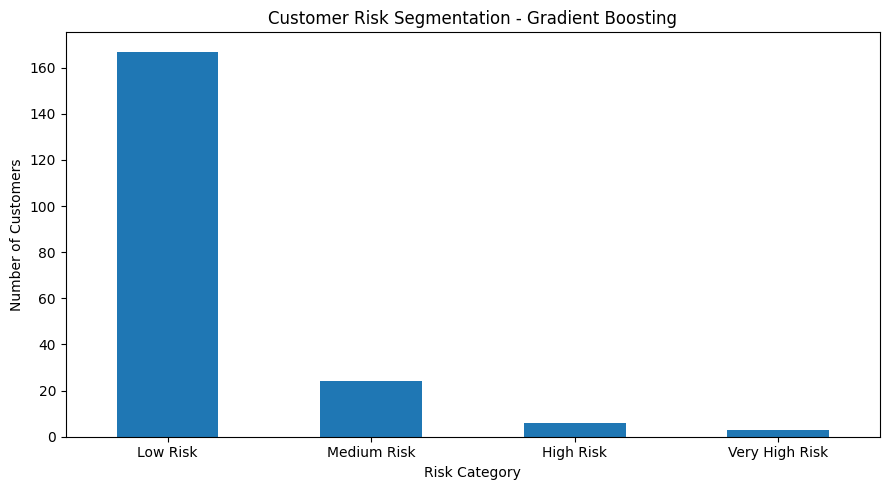

In [ ]:
plt.figure(figsize=(9, 5))

risk_distribution.plot(
    kind='bar'
)

plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.title('Customer Risk Segmentation - Gradient Boosting')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
risk_performance = (
    risk_df
    .groupby('Risk_Category')
    .agg(
        Customers=('Actual_Default', 'count'),
        Actual_Defaults=('Actual_Default', 'sum'),
        Average_Default_Probability=('Default_Probability', 'mean')
    )
    .reindex([
        'Low Risk',
        'Medium Risk',
        'High Risk',
        'Very High Risk'
    ])
)

risk_performance['Actual_Default_Rate'] = (
    risk_performance['Actual_Defaults']
    / risk_performance['Customers']
)

risk_performance['Actual_Default_Rate'] = (
    risk_performance['Actual_Default_Rate'] * 100
).round(2)

risk_performance

,Customers,Actual_Defaults,Average_Default_Probability,Actual_Default_Rate
Risk_Category,,,,
Low Risk,167,7,0.032310,4.19
Medium Risk,24,6,0.151688,25.00
High Risk,6,1,0.399414,16.67
Very High Risk,3,0,0.620421,0.00


In [ ]:
from sklearn.metrics import brier_score_loss

gb_brier_score = brier_score_loss(
    y_test,
    final_gb_probabilities
)

print("Gradient Boosting Brier Score:", round(gb_brier_score, 4))

Gradient Boosting Brier Score: 0.0708


In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    final_gb_probabilities,
    n_bins=5,
    strategy='quantile'
)

print("Mean predicted probability:")
print(prob_pred)

print("\nActual default frequency:")
print(prob_true)

Mean predicted probability:
[0.01375654 0.02045423 0.03051027 0.05483376 0.21304821]

Actual default frequency:
[0.05       0.02439024 0.07692308 0.025      0.175     ]


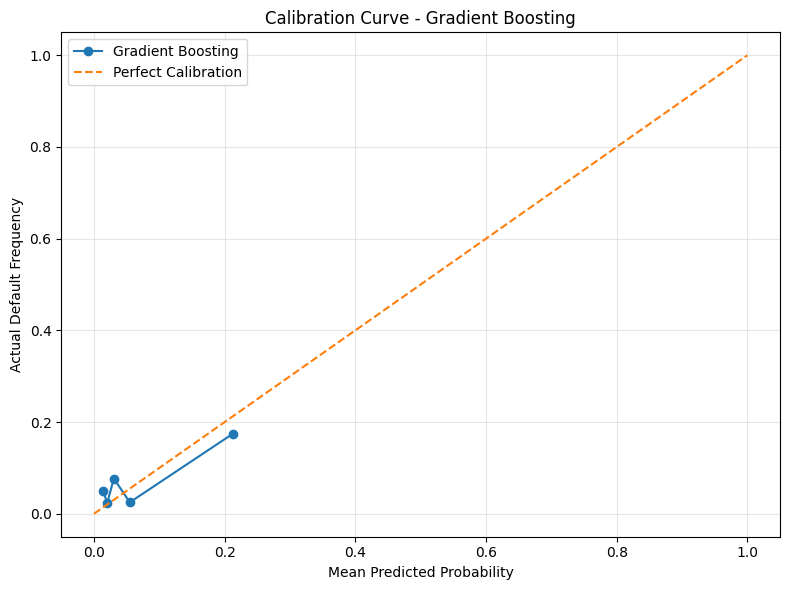

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='Gradient Boosting'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Actual Default Frequency')

plt.title('Calibration Curve - Gradient Boosting')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Select one customer from the test dataset
customer_index = 0

customer_data = X_test_processed[customer_index:customer_index + 1]

print("Customer processed shape:", customer_data.shape)

Customer processed shape: (1, 275)


In [ ]:
# Create SHAP explainer for the Gradient Boosting model
explainer = shap.TreeExplainer(gradient_boosting_model)

# Calculate SHAP values for our selected customer
customer_shap_values = explainer.shap_values(customer_data)

print("SHAP values shape:", customer_shap_values.shape)

SHAP values shape: (1, 275)


In [ ]:
# Get SHAP values for our selected customer
customer_shap = customer_shap_values[0]

# Create a table containing feature names and SHAP values
customer_shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Value': customer_shap
})

# Calculate absolute SHAP value
customer_shap_df['Absolute_SHAP'] = (
    customer_shap_df['SHAP_Value'].abs()
)

# Sort by importance
customer_shap_df = (
    customer_shap_df
    .sort_values('Absolute_SHAP', ascending=False)
    .reset_index(drop=True)
)

# Show top 15 features
customer_shap_df.head(15)

,Feature,SHAP_Value,Absolute_SHAP
0,num__EXT_SOURCE_2,0.341020,0.341020
1,num__DAYS_LAST_PHONE_CHANGE,0.121723,0.121723
2,num__EMPLOYMENT_YEARS,-0.118111,0.118111
3,num__HOUR_APPR_PROCESS_START,-0.098173,0.098173
4,num__CREDIT_GOODS_RATIO,0.057027,0.057027
5,num__CREDIT_INCOME_RATIO,-0.056514,0.056514
6,num__EXT_SOURCE_3,-0.039365,0.039365
7,num__AMT_REQ_CREDIT_BUREAU_YEAR,0.038781,0.038781
8,num__DAYS_ID_PUBLISH,-0.021447,0.021447
9,num__OWN_CAR_AGE,0.017115,0.017115


In [ ]:
# Get the original feature values for this customer
customer_original = X_test.iloc[customer_index]

# Create explanation table
customer_explanation = customer_shap_df.copy()

# Convert processed feature names back to original feature names
customer_explanation['Original_Feature'] = (
    customer_explanation['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

# Add original value where possible
customer_explanation['Feature_Value'] = (
    customer_explanation['Original_Feature']
    .map(customer_original)
)

# Add direction
customer_explanation['Direction'] = customer_explanation['SHAP_Value'].apply(
    lambda x: 'Increases Default Risk' if x > 0
    else 'Decreases Default Risk'
)

# Show top 15
customer_explanation[
    ['Original_Feature', 'Feature_Value', 'SHAP_Value', 'Direction']
].head(15)

,Original_Feature,Feature_Value,SHAP_Value,Direction
0,EXT_SOURCE_2,0.430618,0.341020,Increases Default Risk
1,DAYS_LAST_PHONE_CHANGE,-149.0,0.121723,Increases Default Risk
2,EMPLOYMENT_YEARS,5.190965,-0.118111,Decreases Default Risk
3,HOUR_APPR_PROCESS_START,16,-0.098173,Decreases Default Risk
4,CREDIT_GOODS_RATIO,1.1584,0.057027,Increases Default Risk
5,CREDIT_INCOME_RATIO,2.78016,-0.056514,Decreases Default Risk
6,EXT_SOURCE_3,0.533482,-0.039365,Decreases Default Risk
7,AMT_REQ_CREDIT_BUREAU_YEAR,1.0,0.038781,Increases Default Risk
8,DAYS_ID_PUBLISH,-4265,-0.021447,Decreases Default Risk
9,OWN_CAR_AGE,21.0,0.017115,Increases Default Risk


In [ ]:
# Get predicted default probability for this customer
customer_probability = final_gb_probabilities[customer_index]

print("Customer Default Probability:",
      round(customer_probability, 4))

print("Customer Default Probability (%):",
      round(customer_probability * 100, 2), "%")

Customer Default Probability: 0.042
Customer Default Probability (%): 4.2 %


In [ ]:
# Challenges and limitations identified during the project

challenges_limitations = pd.DataFrame({
    'Challenge / Limitation': [
        'Class Imbalance',
        'Small Dataset',
        'Limited Default Cases in Test Set',
        'Sampled Historical Tables',
        'Missing Values',
        'DAYS_EMPLOYED Anomaly',
        'High-Dimensional Features',
        'Classification Threshold',
        'Potential Temporal Leakage',
        'Probability Calibration',
        'Risk Segment Stability'
    ],

    'Impact': [
        'Only about 7% of customers are defaulters, making accuracy misleading.',
        'Only 1,000 application records were used for the modeling exercise.',
        'Only 14 default cases were present in the test set, making recall and precision unstable.',
        'Historical tables were loaded using sampled rows, so customer history may be incomplete.',
        'Several original and engineered features contained missing values.',
        'DAYS_EMPLOYED contained unrealistic positive values such as 365243.',
        'Categorical encoding expanded 160 input features to 275 processed features.',
        'A 0.50 threshold failed to identify default cases for some models.',
        'Historical records were not restricted using a strict time cutoff before the current application.',
        'Only a small test set was available for reliable calibration assessment.',
        'Some high-risk segments contained very few customers, making default rates unstable.'
    ],

    'Mitigation / Handling': [
        'Used stratified splitting, class weighting, PR-AUC, cross-validation and threshold optimization.',
        'Used cross-validation and treated results as an analytical proof of concept.',
        'Reported metrics cautiously and emphasized recall/PR-AUC rather than accuracy alone.',
        'Documented sampling as a limitation and recommended using complete historical tables.',
        'Used appropriate filling strategies for numerical and categorical features.',
        'Converted unrealistic positive values to missing values and imputed them using valid observations.',
        'Used StandardScaler and OneHotEncoder with a ColumnTransformer.',
        'Selected the final threshold using out-of-fold predictions rather than the default 0.50 threshold.',
        'Identified temporal leakage as a limitation and recommended time-aware feature engineering.',
        'Used calibration curves and Brier score as an analytical check.',
        'Reported segment sizes and avoided treating small segment rates as reliable estimates.'
    ]
})

challenges_limitations

,Challenge / Limitation,Impact,Mitigation / Handling
0,Class Imbalance,"Only about 7% of customers are defaulters, mak...","Used stratified splitting, class weighting, PR..."
1,Small Dataset,"Only 1,000 application records were used for t...",Used cross-validation and treated results as a...
2,Limited Default Cases in Test Set,Only 14 default cases were present in the test...,Reported metrics cautiously and emphasized rec...
3,Sampled Historical Tables,Historical tables were loaded using sampled ro...,Documented sampling as a limitation and recomm...
4,Missing Values,Several original and engineered features conta...,Used appropriate filling strategies for numeri...
5,DAYS_EMPLOYED Anomaly,DAYS_EMPLOYED contained unrealistic positive v...,Converted unrealistic positive values to missi...
6,High-Dimensional Features,Categorical encoding expanded 160 input featur...,Used StandardScaler and OneHotEncoder with a C...
7,Classification Threshold,A 0.50 threshold failed to identify default ca...,Selected the final threshold using out-of-fold...
8,Potential Temporal Leakage,Historical records were not restricted using a...,Identified temporal leakage as a limitation an...
9,Probability Calibration,Only a small test set was available for reliab...,Used calibration curves and Brier score as an ...


In [ ]:
# Final project summary

final_project_summary = {
    "Total Customers": len(model_data),
    "Total Features Before Preprocessing": X.shape[1],
    "Training Samples": X_train.shape[0],
    "Testing Samples": X_test.shape[0],
    "Training Features After Preprocessing": X_train_processed.shape[1],
    "Default Cases": int(y.sum()),
    "Non-Default Cases": int((y == 0).sum()),
    "Default Rate": round(y.mean() * 100, 2),
    "Final Model": "Gradient Boosting",
    "Selected Threshold": 0.08,
    "Final ROC-AUC": round(roc_auc_score(y_test, gb_prob), 4),
    "Final PR-AUC": round(average_precision_score(y_test, gb_prob), 4),
    "Final Accuracy": 0.795,
    "Final Precision": 0.1707,
    "Final Recall": 0.5000,
    "Final F1 Score": 0.2545,
    "Best CV ROC-AUC": 0.7348
}

final_project_summary

{'Total Customers': 1000,
 'Total Features Before Preprocessing': 160,
 'Training Samples': 800,
 'Testing Samples': 200,
 'Training Features After Preprocessing': 275,
 'Default Cases': 70,
 'Non-Default Cases': 930,
 'Default Rate': np.float64(7.0),
 'Final Model': 'Gradient Boosting',
 'Selected Threshold': 0.08,
 'Final ROC-AUC': np.float64(0.6576),
 'Final PR-AUC': np.float64(0.1453),
 'Final Accuracy': 0.795,
 'Final Precision': 0.1707,
 'Final Recall': 0.5,
 'Final F1 Score': 0.2545,
 'Best CV ROC-AUC': 0.7348}

In [ ]:
# ==========================================
# FINAL MODEL VALIDATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss
)

# Generate final probabilities
final_gb_probabilities = gradient_boosting_model.predict_proba(X_test_processed)[:, 1]

# Final threshold selected using OOF predictions
FINAL_THRESHOLD = 0.08

# Convert probabilities into predictions
final_gb_predictions = (
    final_gb_probabilities >= FINAL_THRESHOLD
).astype(int)

print("Final Threshold:", FINAL_THRESHOLD)
print("Predicted Defaults:", final_gb_predictions.sum())
print("Actual Defaults:", y_test.sum())

print("\n--- FINAL MODEL PERFORMANCE ---")

print("Accuracy :", round(
    accuracy_score(y_test, final_gb_predictions), 4
))

print("Precision:", round(
    precision_score(y_test, final_gb_predictions, zero_division=0), 4
))

print("Recall   :", round(
    recall_score(y_test, final_gb_predictions, zero_division=0), 4
))

print("F1 Score :", round(
    f1_score(y_test, final_gb_predictions, zero_division=0), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, final_gb_probabilities), 4
))

print("PR-AUC   :", round(
    average_precision_score(y_test, final_gb_probabilities), 4
))

print("Brier Score:", round(
    brier_score_loss(y_test, final_gb_probabilities), 4
))

print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, final_gb_predictions))

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(
    y_test,
    final_gb_predictions,
    target_names=["Non-Defaulter", "Defaulter"],
    zero_division=0
))

Final Threshold: 0.08
Predicted Defaults: 41
Actual Defaults: 14

--- FINAL MODEL PERFORMANCE ---
Accuracy : 0.795
Precision: 0.1707
Recall   : 0.5
F1 Score : 0.2545
ROC-AUC  : 0.6576
PR-AUC   : 0.1453
Brier Score: 0.0708

--- CONFUSION MATRIX ---
[[152  34]
 [  7   7]]

--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

Non-Defaulter       0.96      0.82      0.88       186
    Defaulter       0.17      0.50      0.25        14

     accuracy                           0.80       200
    macro avg       0.56      0.66      0.57       200
 weighted avg       0.90      0.80      0.84       200



In [ ]:
# ==========================================
# FINAL MODEL COMPARISON
# ==========================================

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Test Accuracy': [
        0.7900,
        0.7050,
        0.9300,
        0.9150
    ],

    'Test Precision': [
        0.1500,
        0.1186,
        0.0000,
        0.0000
    ],

    'Test Recall': [
        0.4286,
        0.5000,
        0.0000,
        0.0000
    ],

    'Test F1': [
        0.2222,
        0.1918,
        0.0000,
        0.0000
    ],

    'Test ROC-AUC': [
        0.6813,
        0.6050,
        0.6494,
        0.6576
    ],

    'Test PR-AUC': [
        0.1532,
        0.1002,
        0.1191,
        0.1453
    ],

    'CV ROC-AUC Mean': [
        0.6242,
        0.6402,
        0.6732,
        0.7348
    ],

    'CV ROC-AUC Std': [
        0.0335,
        0.0832,
        0.0242,
        0.0499
    ]
})

model_comparison

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC,CV ROC-AUC Mean,CV ROC-AUC Std
0,Logistic Regression,0.790,0.1500,0.4286,0.2222,0.6813,0.1532,0.6242,0.0335
1,Decision Tree,0.705,0.1186,0.5000,0.1918,0.6050,0.1002,0.6402,0.0832
2,Random Forest,0.930,0.0000,0.0000,0.0000,0.6494,0.1191,0.6732,0.0242
3,Gradient Boosting,0.915,0.0000,0.0000,0.0000,0.6576,0.1453,0.7348,0.0499


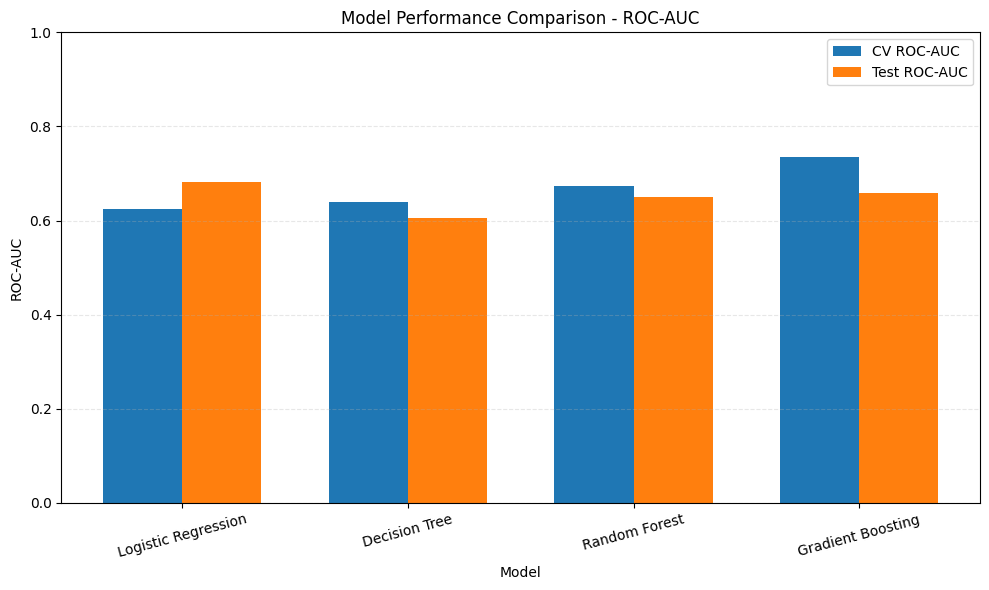

In [ ]:
# ==========================================
# CLEAN MODEL COMPARISON - ROC-AUC
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

models = model_comparison['Model']
cv_scores = model_comparison['CV ROC-AUC Mean']
test_scores = model_comparison['Test ROC-AUC']

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    cv_scores,
    width,
    label='CV ROC-AUC'
)

plt.bar(
    x + width/2,
    test_scores,
    width,
    label='Test ROC-AUC'
)

plt.ylabel('ROC-AUC')
plt.xlabel('Model')
plt.title('Model Performance Comparison - ROC-AUC')
plt.xticks(x, models, rotation=15)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
import json

notebook_path = '/content/PRCP_1006_HomeLoanDefault_v3.ipynb'

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code':
        code = ''.join(cell['source'])

        if "X = model_data.drop(columns=['TARGET', 'SK_ID_CURR'])" in code:
            print("X/Y cell:", i)
            print(code)

        if "risk_df = pd.DataFrame" in code:
            print("\nRisk DataFrame cell:", i)
            print(code)

FileNotFoundError: [Errno 2] No such file or directory: '/content/PRCP_1006_HomeLoanDefault_v3.ipynb'

In [2]:
import os

print("Available notebooks in /content:\n")

for file in os.listdir('/content'):
    if file.endswith('.ipynb'):
        print(file)


Available notebooks in /content:



In [3]:
from google.colab import files

uploaded = files.upload()

Saving PRCP_1006_HomeLoanDefault_v3.ipynb to PRCP_1006_HomeLoanDefault_v3.ipynb


In [4]:
import os

print(os.listdir('/content'))

['.config', 'PRCP_1006_HomeLoanDefault_v3.ipynb', 'sample_data']


In [5]:
import json

notebook_path = '/content/PRCP_1006_HomeLoanDefault_v3.ipynb'

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code':
        code = ''.join(cell['source'])

        if "X = model_data.drop(columns=['TARGET', 'SK_ID_CURR'])" in code:
            print("X/Y cell:", i)
            print(code)

        if "risk_df = pd.DataFrame" in code:
            print("\nRisk DataFrame cell:", i)
            print(code)


Risk DataFrame cell: 205
# Create risk analysis dataframe

risk_df = pd.DataFrame({
    'SK_ID_CURR': X_test.index,
    'Actual_Default': y_test.values,
    'Default_Probability': final_gb_probabilities
})

# Use our selected threshold
selected_threshold = 0.08

risk_df['Predicted_Default'] = (
    risk_df['Default_Probability'] >= selected_threshold
).astype(int)

risk_df.head(10)


In [7]:
# Find the cell containing X and y preparation

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code':
        code = ''.join(cell['source'])

        if "TARGET" in code and "SK_ID_CURR" in code and "train_test_split" in code:
            print("=" * 70)
            print("POSSIBLE X/Y CELL:", i)
            print("=" * 70)
            print(code)

In [8]:
import os

print(os.path.exists('/content/PRCP_1006_HomeLoanDefault_v3.ipynb'))
print(os.listdir('/content'))

True
['.config', 'PRCP_1006_HomeLoanDefault_v3.ipynb', 'sample_data']


In [9]:
import json

notebook_path = '/content/PRCP_1006_HomeLoanDefault_v3.ipynb'

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = json.load(f)

print("Total cells:", len(nb['cells']))

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code':
        code = ''.join(cell['source'])

        if "SK_ID_CURR" in code:
            print("\n" + "="*60)
            print("CELL:", i)
            print("="*60)
            print(code[:1500])

Total cells: 225

CELL: 8
application_sample[
    [
        'SK_ID_CURR',
        'TARGET',
        'AMT_INCOME_TOTAL',
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'AMT_GOODS_PRICE'
    ]
].head(10)

CELL: 36
bureau_summary = bureau_sample.groupby('SK_ID_CURR').agg(
    PREVIOUS_CREDIT_COUNT=('SK_ID_BUREAU', 'count'),
    TOTAL_CREDIT=('AMT_CREDIT_SUM', 'sum'),
    TOTAL_DEBT=('AMT_CREDIT_SUM_DEBT', 'sum'),
    TOTAL_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    MAX_OVERDUE_DAYS=('CREDIT_DAY_OVERDUE', 'max')
).reset_index()

bureau_summary.head()

CELL: 37
active_summary = (
    bureau_sample.assign(
        ACTIVE_CREDIT=lambda x: (x['CREDIT_ACTIVE'] == 'Active').astype(int)
    )
    .groupby('SK_ID_CURR')['ACTIVE_CREDIT']
    .sum()
    .reset_index(name='ACTIVE_CREDIT_COUNT')
)

active_summary.head()

CELL: 72
late_payment_count = (
    installments_sample
    .assign(IS_LATE=(
        installments_sample['PAYMENT_DELAY'] > 0
    ).astype(int))
    .groupby('SK_ID_CURR')[